**1. Loading of scenes and labelling of locations**

Imports

In [1]:
%load_ext autoreload
%autoreload 2

import os
os.environ["CUDA_LAUNCH_BLOCKING"] = "1"
import torch
import torch.nn as nn
from pathlib import Path
import numpy as np
import json
import oxford_data_processing as pp
import training_tools as tt

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Using device: {device}")

Using device: cuda


In [3]:
#imports for tensorboard

from torch.utils.tensorboard import SummaryWriter
log_dir = os.path.join("runs", "training_v2_lange_oxford_ohne_ikt")
writer = SummaryWriter(log_dir=log_dir)
print(f"TensorBoard initialisiert. Starte die Visualisierung im Terminal mit:")
print(f"tensorboard --logdir={log_dir}")

TensorBoard initialisiert. Starte die Visualisierung im Terminal mit:
tensorboard --logdir=runs/training_v2_lange_oxford_ohne_ikt


Define Hyperparameters

In [4]:
#%load_ext tensorboard
# Das '!' zwingt Jupyter, den Befehl direkt im System-Terminal deiner venv auszuführen
#!tensorboard --logdir logs/ --port 6006

In [4]:
spatial_filtering_dist_threshold = 0.1
spatial_filtering_rot_threshold = 3.0

#only used in the old version without subroutes
location_clustering_dist_threshold = 1.5
location_clustering_rot_weight = 1.0

# only used in the new version with subroutes
subroutes_dist_threshold = 10.0
subroutes_rot_threshold = 45.0
location_clustering_dist_threshold_new = 3.0
location_clustering_rot_threshold_new = 10.0
min_imgs_per_cluster = 1
max_imgs_per_cluster = 5
num_subroutes = 10

day_night_pairing_dist_threshold = 3.0
day_night_pairing_rot_threshold = 10.0
alpha = 50.0
num_epochs = 1

cossim_difference_threshold = 0.15

use_oxford_with_ikt = False

In [5]:
import gc
import torch

# 1. Lösche die Referenzen auf deine Modelle und Optimizer
# (Ersetze 'model' und 'optimizer' durch deine Variablennamen)
if 'model' in locals(): del model
if 'optimizer' in locals(): del optimizer

# 2. Python-Müllabfuhr triggern
gc.collect()

# 3. PyTorch zwingen, den VRAM komplett freizugeben
torch.cuda.empty_cache()

# 4. Optional: CUDA-Kontext zurücksetzen (leert den Speicher radikal)
torch.cuda.ipc_collect()

Define paths and select a test scene (the rest is used for training)

In [ ]:
dataset_dir = Path('/home/paul-hoheisel/Documents/SITD-setup-and-data/day-and-night-data/aria')
darkDriving_dir = Path('/home/paul-hoheisel/Documents/DarkDriving_Base/')
outputs = Path('outputs/oxford_hloc')

all_scenes = ['bodleian-library', 'hb-allen-centre', 'keble-college', 'observatory-quarter', 'oxford-robotics-institute']
all_scenes_image_subfoldernames = ['day_night_44', 'day_night_10', 'day_night_24', 'day_night_25', 'day_night_21']
all_scenes_day_subfoldernames = ['day_23', 'day_6', 'day_13', 'day_13', 'day_13']
all_scenes_night_subfoldernames = ['night_21', 'night_4', 'night_11', 'night_12', 'night_08']
test_scene = 0
test_scene_dir = dataset_dir / all_scenes[test_scene]
test_img_subfolder = all_scenes_image_subfoldernames[test_scene]
test_images_root = test_scene_dir / f'ns_processed/multi/undistorted_all_valid/{test_img_subfolder}/camera-rgb'

# select scene for training

train_scenes = [2, 3, 4]  # Alle Szenen außer der Test-Szene (0)
evaluation_scene = 0
scene_dirs = np.zeros(len(train_scenes), dtype=object)
scene_subfolders = np.array([None] * len(train_scenes), dtype=object)
scene_images_roots = np.array([None] * len(train_scenes), dtype=object)
day_images_roots = np.array([None] * len(train_scenes), dtype=object)
night_images_roots = np.array([None] * len(train_scenes), dtype=object)
for i in range (len(train_scenes)):
    scene = train_scenes[i]
    scene_dirs[i] = dataset_dir / all_scenes[scene]
    scene_subfolders[i] = all_scenes_image_subfoldernames[scene]
    scene_images_roots[i] = scene_dirs[i] / f'ns_processed/multi/undistorted_all_valid/{scene_subfolders[i]}/camera-rgb'
    day_images_roots[i] = scene_dirs[i] / f'ns_processed/multi/undistorted_all_valid/{all_scenes_day_subfoldernames[scene]}/camera-rgb'
    night_images_roots[i] = scene_dirs[i] / f'ns_processed/multi/undistorted_all_valid/{all_scenes_night_subfoldernames[scene]}/camera-rgb'

transforms_path_day = []
transforms_path_night = []
transforms_path_combined = []

for i in range (len(train_scenes)):
    scene = train_scenes[i]
    transforms_path_day.append(Path(f'/home/paul-hoheisel/Documents/SITD-setup-and-data/day-and-night-data/aria/{all_scenes[scene]}/ns_processed/multi/undistorted_all_valid/{all_scenes_day_subfoldernames[scene]}/transforms_opencv.json'))
    transforms_path_night.append(Path(f'/home/paul-hoheisel/Documents/SITD-setup-and-data/day-and-night-data/aria/{all_scenes[scene]}/ns_processed/multi/undistorted_all_valid/{all_scenes_night_subfoldernames[scene]}/transforms_opencv.json'))
    transforms_path_combined.append(Path(f'/home/paul-hoheisel/Documents/SITD-setup-and-data/day-and-night-data/aria/{all_scenes[scene]}/ns_processed/multi/undistorted_all_valid/{scene_subfolders[i]}/transforms_opencv.json'))

print(transforms_path_combined)

[PosixPath('/home/paul-hoheisel/Documents/SITD-setup-and-data/day-and-night-data/aria/keble-college/ns_processed/multi/undistorted_all_valid/day_night_24/transforms_opencv.json'), PosixPath('/home/paul-hoheisel/Documents/SITD-setup-and-data/day-and-night-data/aria/observatory-quarter/ns_processed/multi/undistorted_all_valid/day_night_25/transforms_opencv.json'), PosixPath('/home/paul-hoheisel/Documents/SITD-setup-and-data/day-and-night-data/aria/oxford-robotics-institute/ns_processed/multi/undistorted_all_valid/day_night_21/transforms_opencv.json')]


In [7]:
# new version with subroutes

optimized_subroutes = True
use_subroutes = False

if optimized_subroutes:
    use_subroutes = True

day_image_names = []
night_image_names = []
day_dict = []
night_dict = []
day_labels = []
pairs = []
night_labels = []
NUM_CLASSES = []
if use_subroutes:
    subroutes = []
cluster_center_labeled_dict = []
for i in range(len(train_scenes)):
 
    day_image_names.append(pp.get_image_names(transforms_path_day[i]))
    night_image_names.append(pp.get_image_names(transforms_path_night[i]))

    day_dict_, night_dict_ = pp.get_pose_dicts(transforms_path_combined[i], day_image_names[i], night_image_names[i])
    print(f"Length of day and night dicts: {len(day_dict_), len(night_dict_)}")

    if optimized_subroutes:
        new_day_labels, new_subroutes, cluster_centers_dict = pp.build_optimized_subroutes(day_image_names=day_image_names[i], day_pose_dict=day_dict_,
                dist_threshold=location_clustering_dist_threshold_new, rot_threshold=location_clustering_rot_threshold_new,
                min_imgs_per_cluster=min_imgs_per_cluster, max_imgs_per_cluster=max_imgs_per_cluster, num_subroutes=num_subroutes)
        day_labels.append(new_day_labels)
        subroutes.append(new_subroutes)
        cluster_center_labeled_dict.append(cluster_centers_dict)
        print(f"Assigned {len(set(cluster_centers_dict))} clusters to {len(day_labels[i])} day images.")
        print(f"Constructed {len(set(subroutes[i].keys()))} subroutes from {len(day_labels[i])} day images.")
        print(f"Subroutes: {subroutes[i]}")

        new_pairs = pp.find_best_day_night_pairs_optimized(poses_night=night_dict_, poses_day=day_dict_,
                                                        day_labels=new_day_labels, dist_threshold=day_night_pairing_dist_threshold,
                                                        angle_threshold=day_night_pairing_rot_threshold)
        pairs.append(new_pairs)
        new_day_dict = pp.filter_pose_dict(new_day_labels, day_dict_)
        night_dict.append(night_dict_)
        day_dict.append(new_day_dict)
    else:
        day_dict.append(pp.spatial_filtering(day_dict_, dist_threshold=spatial_filtering_dist_threshold, angle_threshold=spatial_filtering_rot_threshold))
        night_dict.append(pp.spatial_filtering(night_dict_, dist_threshold=spatial_filtering_dist_threshold, angle_threshold=spatial_filtering_rot_threshold))

        print(f"After spatial filtering: {len(day_dict_)} day images, {len(night_dict_)} night images.")

        #day_labels.append(cluster_poses_with_matrices(day_image_names=list(day_dict_.keys()), day_pose_dict=day_dict_, dist_threshold=location_clustering_dist_threshold, rot_weight=location_clustering_rot_weight))
        labels, cluster_centers, number_of_assigned_clusters = pp.cluster_poses_via_thresholds(rot_threshold=location_clustering_rot_threshold_new, dist_threshold=location_clustering_dist_threshold_new, day_image_names=list(day_dict_.keys()), day_pose_dict=day_dict_)
        day_labels.append(labels)
        print(f"Assigned {len(set(cluster_centers))} (should be the same as {number_of_assigned_clusters}) clusters to {len(day_labels[i])} day images.")

        if use_subroutes:
            new_subroutes = pp.construct_subroutes(labels=day_labels[i], cluster_centers=cluster_centers, day_pose_dict=day_dict_, dist_threshold=subroutes_dist_threshold, angle_threshold=subroutes_rot_threshold)
            #new_subroutes = filter_subroutes(subroutes=new_subroutes, min_size=20)
            subroutes.append(new_subroutes)
            print(f"Constructed {len(set(subroutes[i].keys()))} subroutes from {len(day_labels[i])} day images.")
            print(f"Subroutes: {subroutes[i]}")
        else: new_subroutes = None

        cluster_center_labeled_dict.append({c: cluster_centers[c] for c in range(len(cluster_centers))})

        new_pairs = pp.find_best_day_night_pairs(night_dict_, day_dict_, dist_threshold=day_night_pairing_dist_threshold, angle_threshold=day_night_pairing_rot_threshold, day_labels=day_labels[i], subroutes=new_subroutes)
        pairs.append(new_pairs)
    print(f"Found {len(pairs[i])} valid day-night pairs from {len(night_dict_)} night and {len(day_dict_)} day images.")

    night_labels.append({n: label for (n, _, _, _, label) in pairs[i] if label is not None}) # sind schon bereinigt, weil jedes Bild hier einen day-partner hat

    NUM_CLASSES.append(len(set(night_labels[i].values())))
sum = 0
for i in range(len(train_scenes)):
    sum += len(pairs[i])
print(f"Total number of day-night image pairs: {sum}")


filtered_day_labels, filtered_night_labels, filtered_pairs, num_labels, subroutes, cluster_center_labeled_dict_intermediate = pp.filter_labels_to_pairs(day_labels, night_labels, pairs, subroutes=subroutes, cluster_center_labeled_dict=cluster_center_labeled_dict, train_scenes=train_scenes)

final_day_labels, final_night_labels, final_pairs, NUM_TOTAL_CLASSES, subroutes, cluster_center_labeled_dict_flat = pp.combine_labels_across_scenes(filtered_day_labels, filtered_night_labels, filtered_pairs, num_labels, subroutes=subroutes, cluster_center_labeled_dict=cluster_center_labeled_dict_intermediate, train_scenes=train_scenes)
day_labels = final_day_labels
night_labels = final_night_labels
pairs = final_pairs


# create dictionary for cluster centers
for i in range(len(train_scenes)):
    dicto = {}
    centers = cluster_center_labeled_dict_intermediate[i]

    for new_j, old_key in enumerate(sorted(centers.keys())):
        dicto[new_j] = centers[old_key]

    cluster_center_labeled_dict_intermediate[i] = dicto


# make pairs a dictionary for easier access at training
new_pairs = []
for i in range(len(train_scenes)):
    for j in range(len(pairs[i])):
        n, d, dist, angle, label = pairs[i][j]
        dict = {"night_img": n, "day_img": d, "dist": dist, "angle": angle, "label": label}
        new_pairs.append(dict)

# necessary for visualization of cluster centers
day_dict_flat = {}
for i in range(len(train_scenes)):
    day_dict_flat.update(day_dict[i])

print(f"Total number of pairs across all scenes: {len(new_pairs)}")
print(f"Total number of classes: {NUM_TOTAL_CLASSES}")

Length of day and night dicts: (11214, 11227)
Building KD-Tree...
Clustering images...
Initial clusters formed: 2391
Clusters after pruning (<1 imgs removed): 2391
Successfully generated 2391 classes distributed over 10 subroutes.
Assigned 2391 clusters to 7200 day images.
Constructed 10 subroutes from 7200 day images.
Subroutes: {0: [0, 10, 20, 30, 40, 50, 60, 70, 80, 90, 100, 110, 120, 130, 140, 150, 160, 170, 180, 190, 200, 210, 220, 230, 240, 250, 260, 270, 280, 290, 300, 310, 320, 330, 340, 350, 360, 370, 380, 390, 400, 410, 420, 430, 440, 450, 460, 470, 480, 490, 500, 510, 520, 530, 540, 550, 560, 570, 580, 590, 600, 610, 620, 630, 640, 650, 660, 670, 680, 690, 700, 710, 720, 730, 740, 750, 760, 770, 780, 790, 800, 810, 820, 830, 840, 850, 860, 870, 880, 890, 900, 910, 920, 930, 940, 950, 960, 970, 980, 990, 1000, 1010, 1020, 1030, 1040, 1050, 1060, 1070, 1080, 1090, 1100, 1110, 1120, 1130, 1140, 1150, 1160, 1170, 1180, 1190, 1200, 1210, 1220, 1230, 1240, 1250, 1260, 1270, 1280, 

Initialize Day and Night Expert

Data Loading ermoeglichen

In [8]:
# Datensatz instanziieren 

global_path_map = pp.build_path_mapping(scene_images_roots, train_scenes=train_scenes)  # Übergib die Liste der Bildordner der Trainingsszenen
train_dataset = pp.OxfordDayNightDataset(
    pairs=new_pairs, 
    day_labels=day_labels, 
    path_map=global_path_map,
    subroutes=subroutes
)
print(train_dataset.pairs[0])
print(f"length of subroutes: {[len(subroute) for subroute in subroutes.values()]}")

pairs by subroute attribute created with 10 subroutes.
{'night_img': '454353195912.jpg', 'day_img': np.str_('355368178425.jpg'), 'dist': 1.6059165905604902, 'angle': 6.091405232254101, 'label': 685}
length of subroutes: [346, 329, 339, 329, 332, 329, 329, 305, 313, 311]


Validation method (load different scene for validation procedure)

1. load images

In [9]:
val_scene = 0
val_scene_dir = dataset_dir / all_scenes[val_scene]
val_scene_subfolder = all_scenes_image_subfoldernames[val_scene]
val_scene_images_root = val_scene_dir / f'ns_processed/multi/undistorted_all_valid/{val_scene_subfolder}/camera-rgb'
#val_day_images_root = val_scene_dir / f'ns_processed/multi/undistorted_all_valid/{all_scenes_day_subfoldernames[val_scene]}/camera-rgb'
#val_night_images_root = val_scene_dir / f'ns_processed/multi/undistorted_all_valid/{all_scenes_night_subfoldernames[val_scene]}/camera-rgb'

val_transforms_path_combined = Path(f'/home/paul-hoheisel/Documents/SITD-setup-and-data/day-and-night-data/aria/{all_scenes[val_scene]}/ns_processed/multi/undistorted_all_valid/{val_scene_subfolder}/transforms_opencv.json')

val_db_list_path = Path(f'/home/paul-hoheisel/Documents/SITD-setup-and-data/day-and-night-data/aria/{all_scenes[val_scene]}/visual_reloc/imagelists/db_imagelist.txt')
val_day_query_list_path = Path(f'/home/paul-hoheisel/Documents/SITD-setup-and-data/day-and-night-data/aria/{all_scenes[val_scene]}/visual_reloc/imagelists/query_day_imagelist.txt')
val_night_query_list_path = Path(f'/home/paul-hoheisel/Documents/SITD-setup-and-data/day-and-night-data/aria/{all_scenes[val_scene]}/visual_reloc/imagelists/query_night_imagelist.txt')
print(f"Val DB List Path: {val_db_list_path}")

Val DB List Path: /home/paul-hoheisel/Documents/SITD-setup-and-data/day-and-night-data/aria/bodleian-library/visual_reloc/imagelists/db_imagelist.txt


In [10]:
def load_gt_poses(txt_path, json_path):
    """
    Load ground truth poses for images listed in txt file.
    
    Args:
        txt_path: Path to txt file containing image names/paths (one per line, prefixed with "camera-rgb/")
        json_path: Path to JSON file (transforms_opencv.json) containing pose information
        
    Returns:
        poses: Dict mapping clean_image_name -> {'q': quaternion (qw, qx, qy, qz), 't': translation}
    """
    from scipy.spatial.transform import Rotation as R_scipy
    
    # 1. Load image names from txt file
    with open(txt_path, 'r') as f:
        lines = f.readlines()
    
    image_names_from_txt = set()
    for line in lines[3:]:  # Skip header lines
        line = line.strip()
        if not line:
            continue
        # Extract just the filename (remove "camera-rgb/" prefix if present)
        if '/' in line:
            image_name = line.split('/')[-1]  # "vrs00_123456789.jpg"
        else:
            image_name = line
        
        # Clean name (remove vrs prefix to match JSON)
        if '_' in image_name:
            clean_name = image_name.split('_', 1)[1]  # "123456789.jpg"
        else:
            clean_name = image_name
        
        image_names_from_txt.add(clean_name)
    
    #print(f"Loaded {len(image_names_from_txt)} image names from {Path(txt_path).name}")
    
    # 2. Load poses from JSON file
    with open(json_path, 'r') as f:
        data = json.load(f)
    
    poses = {}
    counter = 0
    
    for frame in data['frames']:
        full_path = frame['file_path']
        raw_name = full_path.split('/')[-1]  # "vrs00_59673489879.jpg"
        
        if '_' in raw_name:
            clean_name = raw_name.split('_', 1)[1]  # "59673489879.jpg"
        else:
            clean_name = raw_name
        
        # Only keep poses for images that are in the txt file
        if clean_name not in image_names_from_txt:
            continue
        
        # Extract pose information from transform_matrix
        matrix = np.array(frame['transform_matrix'])
        R_w2c = matrix[0:3, 0:3]
        t_w2c = matrix[0:3, 3]
        
        # Convert rotation matrix to quaternion [qw, qx, qy, qz]
        R_quat = R_scipy.from_matrix(R_w2c)
        q_array = R_quat.as_quat()  # Returns [qx, qy, qz, qw]
        q = np.array([q_array[3], q_array[0], q_array[1], q_array[2]])  # Reorder to [qw, qx, qy, qz]
        
        t = t_w2c
        
        poses[clean_name] = {'q': q, 't': t}
        
    
    print(f"  Total poses matched: {len(poses)}\n")
    return poses


def build_path_mapping_for_validation(image_directory):
    path_mapping = {}
    
    # Durchsucht rekursiv alle Unterordner nach jpgs (oder pngs)

    for file_path in Path(image_directory).rglob("*.jpg"):
        filename = file_path.name
        
        # Schneide das Präfix ab (gleiche Logik wie bei der JSON-Extraktion)
        if '_' in filename:
            short_key = filename.split('_', 1)[1]
        else:
            short_key = filename
            
        path_mapping[short_key] = str(file_path)
        
    return path_mapping



In [11]:
val_db_poses = load_gt_poses(val_db_list_path, val_transforms_path_combined)
val_day_query_poses = load_gt_poses(val_day_query_list_path, val_transforms_path_combined)
val_night_query_poses = load_gt_poses(val_night_query_list_path, val_transforms_path_combined)

# Execute at least once: Build validation path mapping (maps image names to full file paths)
print(f"Building validation path mapping for images in {val_scene_images_root}...")
val_path_map = build_path_mapping_for_validation(str(val_scene_images_root))
print(f"Validation path mapping: {len(val_path_map)} images found in {val_scene_images_root}")

# Verify some paths
if len(val_path_map) > 0:
    sample_keys = list(val_path_map.keys())[:3]
    for key in sample_keys:
        print(f"  Sample: {key} -> {val_path_map[key]}")


  Total poses matched: 2539

  Total poses matched: 1307

  Total poses matched: 2905

Building validation path mapping for images in /home/paul-hoheisel/Documents/SITD-setup-and-data/day-and-night-data/aria/bodleian-library/ns_processed/multi/undistorted_all_valid/day_night_44/camera-rgb...
Validation path mapping: 41081 images found in /home/paul-hoheisel/Documents/SITD-setup-and-data/day-and-night-data/aria/bodleian-library/ns_processed/multi/undistorted_all_valid/day_night_44/camera-rgb
  Sample: 1331390742450.jpg -> /home/paul-hoheisel/Documents/SITD-setup-and-data/day-and-night-data/aria/bodleian-library/ns_processed/multi/undistorted_all_valid/day_night_44/camera-rgb/vrs00_1331390742450.jpg
  Sample: 389598375212.jpg -> /home/paul-hoheisel/Documents/SITD-setup-and-data/day-and-night-data/aria/bodleian-library/ns_processed/multi/undistorted_all_valid/day_night_44/camera-rgb/vrs24_389598375212.jpg
  Sample: 2819354403925.jpg -> /home/paul-hoheisel/Documents/SITD-setup-and-data/day

In [12]:
eval_scene = 0
eval_scene_dir = dataset_dir / all_scenes[eval_scene]
eval_scene_subfolder = all_scenes_image_subfoldernames[eval_scene]
eval_scene_images_root = eval_scene_dir / f'ns_processed/multi/undistorted_all_valid/{eval_scene_subfolder}/camera-rgb'
eval_day_images_root = eval_scene_dir / f'ns_processed/multi/undistorted_all_valid/{all_scenes_day_subfoldernames[eval_scene]}/camera-rgb'
eval_night_images_root = eval_scene_dir / f'ns_processed/multi/undistorted_all_valid/{all_scenes_night_subfoldernames[eval_scene]}/camera-rgb'

eval_transforms_path_day=Path(f'/home/paul-hoheisel/Documents/SITD-setup-and-data/day-and-night-data/aria/{all_scenes[eval_scene]}/ns_processed/multi/undistorted_all_valid/{all_scenes_day_subfoldernames[eval_scene]}/transforms_opencv.json')
eval_transforms_path_night=Path(f'/home/paul-hoheisel/Documents/SITD-setup-and-data/day-and-night-data/aria/{all_scenes[eval_scene]}/ns_processed/multi/undistorted_all_valid/{all_scenes_night_subfoldernames[eval_scene]}/transforms_opencv.json')
eval_transforms_path_combined=Path(f'/home/paul-hoheisel/Documents/SITD-setup-and-data/day-and-night-data/aria/{all_scenes[eval_scene]}/ns_processed/multi/undistorted_all_valid/{eval_scene_subfolder}/transforms_opencv.json')

eval_day_image_names = pp.get_image_names(eval_transforms_path_day)
eval_night_image_names = pp.get_image_names(eval_transforms_path_night)

eval_day_pose_dict, eval_night_pose_dict = pp.get_pose_dicts(eval_transforms_path_combined, eval_day_image_names, eval_night_image_names)

eval_path_map = pp.build_path_mapping(np.array([eval_scene_images_root]), np.array([0]))

In [13]:
# go through eval_day_pose_dict and find out the range of x, y and z coordinates
x_coords = [pose['t'][0] for pose in eval_day_pose_dict.values()]
y_coords = [pose['t'][1] for pose in eval_day_pose_dict.values()]
z_coords = [pose['t'][2] for pose in eval_day_pose_dict.values()]
x_range = (min(x_coords), max(x_coords))
y_range = (min(y_coords), max(y_coords))
z_range = (min(z_coords), max(z_coords))
print(f"X range: {x_range}, Y range: {y_range}, Z range: {z_range}")

X range: (np.float64(-162.52008571025434), np.float64(66.30173740513165)), Y range: (np.float64(-225.2391442347854), np.float64(44.863262445565795)), Z range: (np.float64(-2.1875189183069494), np.float64(0.605341265329015))


In [14]:
thresholds=[(1, 5), (2.5, 10), (3.5, 15), (10, 30)]
dist_thresholds = np.array([3.0, 4.0, 10.0, 50.0, 60.0])
angle_thresholds = np.array([10.0, 20.0, 90.0, 360.0])
sample_size=500
'''
validation_day_to_day = pp.ThresholdPairDataset(dist_thresholds=dist_thresholds, angle_thresholds=angle_thresholds, poses_dict_1=eval_day_pose_dict, 
                                                poses_dict_2=eval_day_pose_dict, image_names_1=eval_day_image_names, 
                                                image_names_2=eval_day_image_names, path_map_1=eval_path_map,
                                                path_map_2=eval_path_map, sample_size=sample_size)

validation_day_to_night = pp.ThresholdPairDataset(dist_thresholds=dist_thresholds, angle_thresholds=angle_thresholds, poses_dict_1=eval_day_pose_dict, 
                                                poses_dict_2=eval_night_pose_dict, image_names_1=eval_day_image_names, 
                                                image_names_2=eval_night_image_names, path_map_1=eval_path_map,
                                                path_map_2=eval_path_map, sample_size=sample_size)

'''
validation_night_to_night = pp.ThresholdPairDataset(dist_thresholds=dist_thresholds, angle_thresholds=angle_thresholds, poses_dict_1=eval_night_pose_dict, 
                                                poses_dict_2=eval_night_pose_dict, image_names_1=eval_night_image_names, 
                                                image_names_2=eval_night_image_names, path_map_1=eval_path_map,
                                                path_map_2=eval_path_map, sample_size=sample_size)


Threshold-based pair generation started:
  threshold 1: (np.float64(3.0), np.float64(10.0)) -> created 500 pairs
  threshold 2: (np.float64(3.0), np.float64(20.0)) -> created 500 pairs
  threshold 3: (np.float64(3.0), np.float64(90.0)) -> created 500 pairs
  threshold 4: (np.float64(3.0), np.float64(360.0)) -> created 500 pairs
  threshold 5: (np.float64(4.0), np.float64(10.0)) -> created 500 pairs
  threshold 6: (np.float64(4.0), np.float64(20.0)) -> created 500 pairs
  threshold 7: (np.float64(4.0), np.float64(90.0)) -> created 500 pairs
  threshold 8: (np.float64(4.0), np.float64(360.0)) -> created 500 pairs
  threshold 9: (np.float64(10.0), np.float64(10.0)) -> created 500 pairs
  threshold 10: (np.float64(10.0), np.float64(20.0)) -> created 500 pairs
  threshold 11: (np.float64(10.0), np.float64(90.0)) -> created 500 pairs
  threshold 12: (np.float64(10.0), np.float64(360.0)) -> created 500 pairs
  threshold 13: (np.float64(50.0), np.float64(10.0)) -> created 500 pairs
  threshold

In [15]:
from torch.utils.data import DataLoader
import torchvision.transforms as T
import torch.nn.functional as F
from torch.utils.data import Dataset

class ValidationDataset(Dataset):
    """
    Validation dataset für Localization-Evaluierung
    Laden von Bildern (DB / Query) mit ihren Ground-Truth Posen
    """
    def __init__(self, image_names, poses_dict, path_map, transform=None):
        """
        image_names: Liste von Bildnamen (werden als Keys in path_map nachgeschlagen)
        poses_dict: Dict mit poses für diese Bilder {'img_name': {'q': quat, 't': trans}}
        path_map: Maps image_name -> full_file_path
        transform: Optional Transformationen (default: ResNet normalisiert)
        """
        self.image_names = image_names
        self.poses = poses_dict
        self.path_map = path_map
        
        self.transform = transform or T.Compose([
            T.Resize((512, 512)),
            T.ToTensor(),
            T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
        ])
    
    def __len__(self):
        return len(self.image_names)
    
    def __getitem__(self, idx):
        img_name = self.image_names[idx]
        
        # Lade Bild
        img_path = self.path_map[img_name]
        img = Image.open(img_path).convert('RGB')
        
        if self.transform:
            img = self.transform(img)
        
        # Hole Pose
        pose = self.poses[img_name]
        
        return {
            'image': img,
            'image_name': img_name,
            'quaternion': torch.tensor(pose['q'], dtype=torch.float32),
            'translation': torch.tensor(pose['t'], dtype=torch.float32)
        }


# Extrahiere Bildnamen aus den geladenen Posen
val_db_image_names = list(val_db_poses.keys())
val_day_query_image_names = list(val_day_query_poses.keys())
val_night_query_image_names = list(val_night_query_poses.keys())

print(f"\nValidation Dataset Summary:")
print(f"  Database Images: {len(val_db_image_names)}")
print(f"  Day Query Images: {len(val_day_query_image_names)}")
print(f"  Night Query Images: {len(val_night_query_image_names)}")

# Erstelle Validation Datasets
val_db_dataset = ValidationDataset(
    image_names=val_db_image_names,
    poses_dict=val_db_poses,
    path_map=val_path_map
)

val_day_query_dataset = ValidationDataset(
    image_names=val_day_query_image_names,
    poses_dict=val_day_query_poses,
    path_map=val_path_map
)

val_night_query_dataset = ValidationDataset(
    image_names=val_night_query_image_names,
    poses_dict=val_night_query_poses,
    path_map=val_path_map
)

print(f"  ✓ ValidationDatasets created successfully")

# Erstelle DataLoaders (kein Shuffling, kein Multi-Processing für Validation)
val_db_loader = DataLoader(val_db_dataset, batch_size=32, shuffle=False, num_workers=0)
val_day_query_loader = DataLoader(val_day_query_dataset, batch_size=32, shuffle=False, num_workers=0)
val_night_query_loader = DataLoader(val_night_query_dataset, batch_size=32, shuffle=False, num_workers=0)

print(f"  ✓ DataLoaders created")
print(f"    - DB Loader: {len(val_db_loader)} batches")
print(f"    - Day Query Loader: {len(val_day_query_loader)} batches")
print(f"    - Night Query Loader: {len(val_night_query_loader)} batches")



Validation Dataset Summary:
  Database Images: 2539
  Day Query Images: 1307
  Night Query Images: 2905
  ✓ ValidationDatasets created successfully
  ✓ DataLoaders created
    - DB Loader: 80 batches
    - Day Query Loader: 41 batches
    - Night Query Loader: 91 batches


In [16]:
# Do the same for the validation dataset
eval_db_list_path = Path(f'/home/paul-hoheisel/Documents/SITD-setup-and-data/day-and-night-data/aria/{all_scenes[eval_scene]}/visual_reloc/imagelists/db_imagelist.txt')
eval_day_query_list_path = Path(f'/home/paul-hoheisel/Documents/SITD-setup-and-data/day-and-night-data/aria/{all_scenes[eval_scene]}/visual_reloc/imagelists/query_day_imagelist.txt')
eval_night_query_list_path = Path(f'/home/paul-hoheisel/Documents/SITD-setup-and-data/day-and-night-data/aria/{all_scenes[eval_scene]}/visual_reloc/imagelists/query_night_imagelist.txt')
print(f"Evaluation DB List Path: {eval_db_list_path}")
eval_db_poses = load_gt_poses(eval_db_list_path, eval_transforms_path_combined)
eval_day_query_poses = load_gt_poses(eval_day_query_list_path, eval_transforms_path_combined)
eval_night_query_poses = load_gt_poses(eval_night_query_list_path, eval_transforms_path_combined)

# Extrahiere Bildnamen aus den geladenen Posen
eval_db_image_names = list(eval_db_poses.keys())
eval_day_query_image_names = list(eval_day_query_poses.keys())
eval_night_query_image_names = list(eval_night_query_poses.keys())

print(f"\nValidation Dataset Summary:")
print(f"  Database Images: {len(eval_db_image_names)}")
print(f"  Day Query Images: {len(eval_day_query_image_names)}")
print(f"  Night Query Images: {len(eval_night_query_image_names)}")

# Erstelle Validation Datasets
eval_db_dataset = ValidationDataset(
    image_names=eval_db_image_names,
    poses_dict=eval_db_poses,
    path_map=eval_path_map
)

eval_day_query_dataset = ValidationDataset(
    image_names=eval_day_query_image_names,
    poses_dict=eval_day_query_poses,
    path_map=eval_path_map
)

eval_night_query_dataset = ValidationDataset(
    image_names=eval_night_query_image_names,
    poses_dict=eval_night_query_poses,
    path_map=eval_path_map
)

print(f"  ✓ ValidationDatasets created successfully")

# Erstelle DataLoaders (kein Shuffling, kein Multi-Processing für Validation)
eval_db_loader = DataLoader(eval_db_dataset, batch_size=32, shuffle=False, num_workers=0)
eval_day_query_loader = DataLoader(eval_day_query_dataset, batch_size=32, shuffle=False, num_workers=0)
eval_night_query_loader = DataLoader(eval_night_query_dataset, batch_size=32, shuffle=False, num_workers=0)

print(f"  ✓ DataLoaders created")
print(f"    - DB Loader: {len(eval_db_loader)} batches")
print(f"    - Day Query Loader: {len(eval_day_query_loader)} batches")
print(f"    - Night Query Loader: {len(eval_night_query_loader)} batches")

Evaluation DB List Path: /home/paul-hoheisel/Documents/SITD-setup-and-data/day-and-night-data/aria/bodleian-library/visual_reloc/imagelists/db_imagelist.txt
  Total poses matched: 2539

  Total poses matched: 1307

  Total poses matched: 2905


Validation Dataset Summary:
  Database Images: 2539
  Day Query Images: 1307
  Night Query Images: 2905
  ✓ ValidationDatasets created successfully
  ✓ DataLoaders created
    - DB Loader: 80 batches
    - Day Query Loader: 41 batches
    - Night Query Loader: 91 batches


In [17]:
def compute_embeddings(model, dataloader, device):
    """
    Compute embeddings für alle Bilder in einem DataLoader
    Gibt zurück: embeddings (N, 512), image_names, poses
    """
    all_embeddings = []
    all_image_names = []
    all_quaternions = []
    all_translations = []
    
    model.eval()
    with torch.no_grad():
        for batch in dataloader:
            images = batch['image'].to(device)
            
            # Compute embeddings
            embeddings = model(images)
            
            all_embeddings.append(embeddings.cpu())
            all_image_names.extend(batch['image_name'])
            all_quaternions.append(batch['quaternion'].cpu())
            all_translations.append(batch['translation'].cpu())
    
    embeddings = torch.cat(all_embeddings, dim=0)  # (N, 512)
    quaternions = torch.cat(all_quaternions, dim=0)  # (N, 4)
    translations = torch.cat(all_translations, dim=0)  # (N, 3)
    
    return embeddings, all_image_names, quaternions, translations


def evaluate_localization(query_embeddings, query_image_names, db_embeddings, db_image_names, 
                          query_poses, db_poses, top_k=5):
    """
    Einfache Nearest-Neighbor Localization Evaluierung
    Compute recall@K: Wie oft ist die Ground-Truth DB-Image in den Top-K Retrievals
    
    Args:
        query_embeddings: (N_q, 512)
        db_embeddings: (N_db, 512)
        query_poses, db_poses: Dicts mit Posen
        top_k: Nur Top-K NNs für Recall berechnen
    
    Returns:
        recalls: Dict mit Recall@1, Recall@5, etc.
    """
    # L2-normalize embeddings
    query_emb_norm = F.normalize(query_embeddings, p=2, dim=1)
    db_emb_norm = F.normalize(db_embeddings, p=2, dim=1)
    
    # Compute similarities: (N_q, N_db)
    similarities = torch.matmul(query_emb_norm, db_emb_norm.t())
    
    # Get Top-K
    _, top_k_indices = torch.topk(similarities, k=top_k, dim=1)  # (N_q, k)
    
    # Evaluate
    recalls = {1: 0, 5: 0, 10: 0}
    
    for q_idx in range(len(query_image_names)):
        q_name = query_image_names[q_idx]
        q_pos = query_poses[q_name]
        q_trans = np.array(q_pos['t'])
        
        # Threshold für korrektes Match (z.B. 25 Meter) TODO: angle fehlt, aber fuer die Benchmarks gar nicht so relevant
        dist_threshold = 25.0
        
        for rank, db_idx in enumerate(top_k_indices[q_idx].tolist()):
            db_name = db_image_names[db_idx]
            db_pos = db_poses[db_name]
            db_trans = np.array(db_pos['t'])
            
            dist = np.linalg.norm(q_trans - db_trans)
            
            if dist < dist_threshold:
                if rank < 1:
                    recalls[1] += 1
                if rank < 5:
                    recalls[5] += 1
                if rank < 10:
                    recalls[10] += 1
                break
    
    # Normalisiere
    n_queries = len(query_image_names)
    recalls[1] = (recalls[1] / n_queries * 100) if n_queries > 0 else 0
    recalls[5] = (recalls[5] / n_queries * 100) if n_queries > 0 else 0
    recalls[10] = (recalls[10] / n_queries * 100) if n_queries > 0 else 0
    
    return recalls


print("✓ Validation helper functions created (compute_embeddings, evaluate_localization)")


✓ Validation helper functions created (compute_embeddings, evaluate_localization)


In [18]:
def validate_during_training(model, val_db_loader, val_day_query_loader, val_night_query_loader, 
                             val_db_image_names, val_day_query_image_names, val_night_query_image_names,
                             val_db_poses, val_day_query_poses, val_night_query_poses,
                             device, epoch):
    """
    Validierungsfunktion zum Aufrufen während des Trainings
    Berechnet Recall@1 und Recall@5 für Day und Night Query Bilder
    """
    print(f"\n{'='*60}")
    print(f"Validation nach Epoch {epoch}")
    print(f"{'='*60}")
    
    # Compute embeddings für alle Splits
    print("  Computing embeddings for database...")
    db_emb, _, _, _ = compute_embeddings(model, val_db_loader, device)
    
    print("  Computing embeddings for day queries...")
    day_query_emb, _, _, _ = compute_embeddings(model, val_day_query_loader, device)
    
    print("  Computing embeddings for night queries...")
    night_query_emb, _, _, _ = compute_embeddings(model, val_night_query_loader, device)
    
    # Evaluate Day Queries
    print("\n  Evaluating Day Queries...")
    day_recalls = evaluate_localization(
        query_embeddings=day_query_emb,
        query_image_names=val_day_query_image_names,
        db_embeddings=db_emb,
        db_image_names=val_db_image_names,
        query_poses=val_day_query_poses,
        db_poses=val_db_poses,
        top_k=10
    )
    
    # Evaluate Night Queries
    print("  Evaluating Night Queries...")
    night_recalls = evaluate_localization(
        query_embeddings=night_query_emb,
        query_image_names=val_night_query_image_names,
        db_embeddings=db_emb,
        db_image_names=val_db_image_names,
        query_poses=val_night_query_poses,
        db_poses=val_db_poses,
        top_k=10
    )
    
    # Print Results
    print(f"\n  Day Queries:")
    print(f"    Recall@1: {day_recalls[1]:.2f}%")
    print(f"    Recall@5: {day_recalls[5]:.2f}%")
    print(f"    Recall@10: {day_recalls[10]:.2f}%")
    
    print(f"\n  Night Queries:")
    print(f"    Recall@1: {night_recalls[1]:.2f}%")
    print(f"    Recall@5: {night_recalls[5]:.2f}%")
    print(f"    Recall@10: {night_recalls[10]:.2f}%")
    
    print(f"{'='*60}\n")
    
    return {
        'day_recall_1': day_recalls[1],
        'day_recall_5': day_recalls[5],
        'day_recall_10': day_recalls[10],
        'night_recall_1': night_recalls[1],
        'night_recall_5': night_recalls[5],
        'night_recall_10': night_recalls[10]
    }


print("✓ validate_during_training function ready")
print("\nUsage during training:")
print("  val_results = validate_during_training(")
print("      model=night_expert,")
print("      val_db_loader=val_db_loader,")
print("      val_day_query_loader=val_day_query_loader,")
print("      val_night_query_loader=val_night_query_loader,")
print("      val_db_image_names=val_db_image_names,")
print("      val_day_query_image_names=val_day_query_image_names,")
print("      val_night_query_image_names=val_night_query_image_names,")
print("      val_db_poses=val_db_poses,")
print("      val_day_query_poses=val_day_query_poses,")
print("      val_night_query_poses=val_night_query_poses,")
print("      device=device,")
print("      epoch=epoch_number")
print("  )")


✓ validate_during_training function ready

Usage during training:
  val_results = validate_during_training(
      model=night_expert,
      val_db_loader=val_db_loader,
      val_day_query_loader=val_day_query_loader,
      val_night_query_loader=val_night_query_loader,
      val_db_image_names=val_db_image_names,
      val_day_query_image_names=val_day_query_image_names,
      val_night_query_image_names=val_night_query_image_names,
      val_db_poses=val_db_poses,
      val_day_query_poses=val_day_query_poses,
      val_night_query_poses=val_night_query_poses,
      device=device,
      epoch=epoch_number
  )


In [19]:
import json
import os
import time
import torch

def save_experiment_results(epoch, night_expert, val_results, train_accuracy, run_losses, config_dict, base_dir="experiments"):
    # Einzigartigen Ordner für diesen Run erstellen (z.B. nach Alpha oder Zeit)
    timestamp = time.strftime("%Y%m%d-%H%M%S")
    run_name = f"run_alpha_{config_dict['alpha']}_{timestamp}"
    save_dir = os.path.join(base_dir, run_name)
    os.makedirs(save_dir, exist_ok=True)
    
    # 1. Model Checkpoint speichern (Nur Gewichte des Night-Experts)
    model_path = os.path.join(save_dir, f"night_expert_epoch_{epoch+1}.pt")
    torch.save(night_expert.state_dict(), model_path)
    
    # 2. Metriken und Hyperparameter aggregieren
    summary = {
        "metadata": {
            "epoch_completed": epoch + 1,
            "timestamp": timestamp
        },
        "hyperparameters": config_dict,
        "metrics": {
            "train_cluster_accuracy": float(train_accuracy),
            # Falls val_results ein Dict mit Recalls ist (z.B. {"R1": 16.18, "R5": 32.53})
            "validation_results": val_results 
        },
        "losses_history": run_losses
    }
    
    # 3. JSON schreiben
    json_path = os.path.join(save_dir, "experiment_summary.json")
    with open(json_path, 'w') as f:
        json.dump(summary, f, indent=4)
        
    print(f"\n[INFO] Ergebnisse erfolgreich gespeichert unter: {save_dir}")



def zero_shot_alignment_of_W(train_dataset: Dataset, NUM_TOTAL_CLASSES):
    # 1. W direkt als PyTorch-Tensor auf dem richtigen Device initialisieren
    W = torch.randn(512, NUM_TOTAL_CLASSES, device=device)
    
    for c in range(NUM_TOTAL_CLASSES):
        
        # Alle Tag-Bilder für diesen Cluster finden
        day_imgs_in_cluster = [pair['day_img'] for pair in train_dataset.pairs if pair['label'] == c]
        descriptors = []
        
        for img_name in day_imgs_in_cluster:
            img_path = train_dataset.path_map[img_name]
            img = Image.open(img_path).convert('RGB')
            
            # 2. Tensor erstellen UND auf die GPU schicken (.to(device))
            img_tensor = train_dataset.transform(img).unsqueeze(0).to(device)
            
            with torch.no_grad():
                # Den Deskriptor auf der GPU belassen
                desc = day_expert(img_tensor)
                descriptors.append(desc)
        
        if descriptors:
            # 3. Mathematische Operationen direkt auf der GPU ausführen (viel schneller!)
            descriptors = torch.cat(descriptors, dim=0)  # entspricht np.vstack
            mean_descriptor = torch.mean(descriptors, dim=0)
            
            # Normalisieren
            mean_descriptor /= torch.norm(mean_descriptor) + 1e-10
            
            # Labelzuweisung im Dataset (bleibt CPU/Python)
            train_dataset.labels[day_imgs_in_cluster[0]] = c
            
            # 4. Jetzt passt es: Tensor in Tensor auf der GPU schreiben
            W[:, c] = mean_descriptor
            
    return W

Load the DarkDriving data

In [20]:
import os
from PIL import Image
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as T


class DarkDrivingDataset(Dataset):
    def __init__(self, root_dir, transform=None, image_names = None):
        """
        Argumente:
            root_dir (string): Pfad zum Hauptordner, der 'day' und 'night' enthält.
            transform (callable, optional): Optionale Transformationen für die Bilder.
        """
        
        self.root_dir = root_dir
        self.day_dir = os.path.join(root_dir, 'Day')
        self.night_dir = os.path.join(root_dir, 'Night')
        self.transform = transform or T.Compose([
            T.Resize((512, 512)), 
            T.ToTensor(),
            T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
        ])

        if image_names is None:
            print("Split was not applied. All images are assigned to the created dataset.")
            self.image_names = [f for f in os.listdir(self.day_dir) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
        else:
            self.image_names = image_names

    def __len__(self):
        return len(self.image_names)

    def __getitem__(self, idx):
        img_name = self.image_names[idx]
        
        # Pfade zu den jeweiligen Bildern erstellen
        day_img_path = os.path.join(self.day_dir, img_name)
        night_img_path = os.path.join(self.night_dir, img_name)
        
        # Bilder laden (als RGB)
        day_image = Image.open(day_img_path).convert('RGB')
        night_image = Image.open(night_img_path).convert('RGB')
        
        # Transformationen (z.B. Resize, ToTensor) auf BEIDE Bilder anwenden
        if self.transform:
            day_image = self.transform(day_image)
            night_image = self.transform(night_image)
            
        # Wir geben das Paar zurück. 
        # Je nach Anwendungsfall (z.B. Image-to-Image Translation wie Pix2Pix) 
        # ist 'day' dein Target/Label und 'night' dein Input (oder umgekehrt).
        return day_image, night_image

In [21]:
val_prefixes = ('1_1_', '2_1_', '3_1_', '4_1_')
test_prefixes = ('1_2_', '2_2_', '3_2_', '4_2_')
train_pairs, val_pairs, test_pairs = pp.create_scene_splits(darkDriving_dir, val_prefixes=val_prefixes, test_prefixes=test_prefixes)

dark_driving_train_dataset = DarkDrivingDataset(root_dir=darkDriving_dir, image_names=train_pairs)
dark_driving_val_dataset = DarkDrivingDataset(root_dir=darkDriving_dir, image_names=val_pairs)
dark_driving_test_dataset = DarkDrivingDataset(root_dir=darkDriving_dir, image_names=test_pairs)


print(f"Anzahl der Bildpaare im Training Dataset: {len(dark_driving_train_dataset)}")

Assigned 7337 train pairs, 1082 val pairs and 1119 test pairs.
Anzahl der Bildpaare im Training Dataset: 7337


In [ ]:
# DO NOT EXECUTE
from torch.utils.data import DataLoader
from torch.optim import SGD

W = zero_shot_alignment_of_W(train_dataset, NUM_TOTAL_CLASSES=NUM_TOTAL_CLASSES)


# DataLoader mit Multi-Processing (num_workers) für schnelles Laden
train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True, num_workers=4)

# Initialisiere beide Module EINMAL vor der Schleife
lmc_module = tt.LMCLoss(num_classes=NUM_CLASSES, W=W).to(device)
ikt_module = tt.IKTLoss().to(device)

# Optimizer Setup: Nur Night Expert wird trainiert
optimizer = SGD(night_expert.parameters(), lr=0.001, momentum=0.9)

# Hyperparameter
#alpha = 10.0  # bzw. 50.0 beim zweiten Run
#num_epochs = 1
compute_benchmark = False


if compute_benchmark:
    # Compute benchmark on validation scene using loaded day_expert
   
    print("COMPUTING BENCHMARK ON VALIDATION SCENE")
    

    # Verify model is available
    if 'day_expert' not in locals():
        print("ERROR: day_expert model not found. Please ensure training is completed first.")
    else:
        # Run validation
        val_results = validate_during_training(
            model=day_expert,
            val_db_loader=val_db_loader,
            val_day_query_loader=val_day_query_loader,
            val_night_query_loader=val_night_query_loader,
            val_db_image_names=val_db_image_names,
            val_day_query_image_names=val_day_query_image_names,
            val_night_query_image_names=val_night_query_image_names,
            val_db_poses=val_db_poses,
            val_day_query_poses=val_day_query_poses,
            val_night_query_poses=val_night_query_poses,
            device=device,
            epoch='FINAL'
        )



print(f"\n{'='*60}")
print(f"Training-Setup:")
print(f"  Dataset Größe: {len(new_pairs)} Sample Pairs")
print(f"  Anzahl Cluster (Klassen): {NUM_CLASSES}")
print(f" Gesamtanzahl Clusters: {NUM_TOTAL_CLASSES}")
print(f"  Batch Größe: 16")
print(f"  Device: {device}")
print(f"  Alpha (IKT Weight): {alpha}")

print(f"spatial_filtering_dist_threshold: {spatial_filtering_dist_threshold}m")
print(f"spatial_filtering_rot_threshold: {spatial_filtering_rot_threshold}°")
print(f"location_clustering_dist_threshold (only for version without subroutes): {location_clustering_dist_threshold}m")
print(f"location_clustering_rot_weight (version with out subroutes): {location_clustering_rot_weight}°")
print(f"day_night_pairing_dist_threshold: {day_night_pairing_dist_threshold}m")
print(f"day_night_pairing_rot_threshold: {day_night_pairing_rot_threshold}°")
print(f"location_clustering_dist_threshold_new: {location_clustering_dist_threshold_new}")
print(f"location_clustering_rot_threshold_new: {location_clustering_rot_threshold_new}")
print(f"min_imgs_per_cluster: {min_imgs_per_cluster}")
print(f"max_imgs_per_cluster: {max_imgs_per_cluster}")
print(f"num_epochs: {num_epochs}")

print(f"{'='*60}\n")

if subroutes is not None:
    num_subroutes = len(subroutes)
    print(f"Anzahl Subrouten: {num_subroutes}")
    subroute_order = list(range(num_subroutes))  # z.B. [0, 1, 2, 3] für 4 Subrouten



# Verfolgung der Loss-Entwicklung über die Batches
epoch_losses = {"lmc": [], "ikt": [], "total": []}

# Deine aktuellen Variablen als Config-Dict zusammenfassen
config_dict = {
    "num_classes": NUM_CLASSES,
    "num_total_classes": NUM_TOTAL_CLASSES,
    "batch_size": 16,
    "alpha": alpha,
    "spatial_filtering_dist_threshold": spatial_filtering_dist_threshold,
    "spatial_filtering_rot_threshold": spatial_filtering_rot_threshold,
    "location_clustering_dist_threshold": location_clustering_dist_threshold,
    "location_clustering_rot_weight": location_clustering_rot_weight,
    "location_clustering_dist_threshold_new": location_clustering_dist_threshold_new,
    "location_clustering_rot_weight_new": location_clustering_rot_threshold_new,
    "day_night_pairing_dist_threshold": day_night_pairing_dist_threshold,
    "day_night_pairing_rot_threshold": day_night_pairing_rot_threshold,
    "num_epochs": num_epochs,
    "min_imgs_per_cluster": min_imgs_per_cluster,
    "max_imgs_per_cluster": max_imgs_per_cluster
}




for epoch in range(num_epochs):
    print(f"Epoch {epoch+1}/{num_epochs}")

    # new part
    
    np.random.shuffle(subroute_order)

    for subroute_idx in subroute_order:
        # 1. Das Dataset auf die aktuelle Subroute umstellen
        train_dataset.set_subroute(list(subroutes.keys())[subroute_idx])
        
        # 2. Den DataLoader neu aufsetzen (kostet in PyTorch keine Zeit)
        # Dadurch werden die internen Indizes für diese Subroute frisch generiert
        train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True, drop_last=True)




    
        for batch_idx, (img_night, img_day, labels) in enumerate(train_loader):
            img_night = img_night.to(device)
            img_day = img_day.to(device)
            labels = labels.to(device)
            
            if batch_idx == 0:
                print(f"  Batch 1 | Shape - Night: {img_night.shape}, Day: {img_day.shape}, Labels: {labels.shape}")
            
            # 1. Feature Extraction
            with torch.no_grad():
                feats_day = day_expert(img_day)  
            feats_night = night_expert(img_night)

            if batch_idx == 0:
                print(f"          | Features - Night: {feats_night.shape}, Day: {feats_day.shape}")

            # 2. Logits via Shared Matrix W generieren
            W_norm = F.normalize(lmc_module.W, p=2, dim=0)
            logits_day = torch.matmul(F.normalize(feats_day, p=2, dim=1), W_norm)
            logits_night = torch.matmul(F.normalize(feats_night, p=2, dim=1), W_norm)

            # 3. Losses berechnen
            loss_lmc = lmc_module(feats_night, labels, subroutes[subroute_idx])
            loss_ikt = ikt_module(logits_night, logits_day)

            # Total Loss nach NocPlace-Formel
            total_loss = loss_lmc + alpha * loss_ikt

            # 4. Backward Pass
            optimizer.zero_grad()
            total_loss.backward()
            optimizer.step()


            # In die Listen appenden für das spätere JSON-Save
            epoch_losses["lmc"].append(loss_lmc.item())
            epoch_losses["ikt"].append(loss_ikt.item())
            epoch_losses["total"].append(total_loss.item())



            # Debugging: Prints nach jedem 5. Batch
            if batch_idx % 5 == 0:
                print(f"  Batch {batch_idx+1:3d} | LMC Loss: {loss_lmc.item():.6f} | IKT Loss: {loss_ikt.item():.6f} | Total: {total_loss.item():.6f}")
            
            # Nur beim allerersten Batch: Mehr Details
            if batch_idx == 0:
                print(f"          | Label-Verteilung: min={labels.min().item()}, max={labels.max().item()}")
    


    # NEU
    val_results = validate_during_training(
        model=night_expert,
        val_db_loader=val_db_loader,
        val_day_query_loader=val_day_query_loader,
        val_night_query_loader=val_night_query_loader,
        val_db_image_names=val_db_image_names,
        val_day_query_image_names=val_day_query_image_names,
        val_night_query_image_names=val_night_query_image_names,
        val_db_poses=val_db_poses,
        val_day_query_poses=val_day_query_poses,
        val_night_query_poses=val_night_query_poses,
        device=device,
        epoch=epoch
    )





    print(f"Evaluiere cluster assignment accuracy auf training set nach Epoch {epoch+1}...")
    predicted_labels = []
    true_labels = []
    for img_night, img_day, labels in train_loader:
        img_night = img_night.to(device)
        img_day = img_day.to(device)
        labels = labels.to(device)
        
        with torch.no_grad():
            feats_night = night_expert(img_night)
            W_norm = F.normalize(lmc_module.W, p=2, dim=0)
            logits_night = torch.matmul(F.normalize(feats_night, p=2, dim=1), W_norm)
            preds = torch.argmax(logits_night, dim=1)
            predicted_labels.extend(preds.cpu().numpy())
            true_labels.extend(labels.cpu().numpy())
    predicted_labels = np.array(predicted_labels)
    true_labels = np.array(true_labels)
    accuracy = np.mean(predicted_labels == true_labels)
    print(f"  Cluster Assignment Accuracy auf Training Set: {accuracy*100:.2f}%\n")

    
    # JETZT SPEICHERN
    '''
    save_experiment_results(
        epoch=epoch,
        night_expert=night_expert,
        val_results=val_results,        # Die Rückgabe aus validate_during_training
        train_accuracy=accuracy,        # Die berechnete Cluster Accuracy
        run_losses=epoch_losses,        # Die aufgezeichneten Losses dieser Epoche
        config_dict=config_dict
    )
    '''


W was initialized by zero-shot alignment

Training-Setup:
  Dataset Größe: 21753 Sample Pairs
  Anzahl Cluster (Klassen): [374, 1351, 1090, 821]
 Gesamtanzahl Clusters: 3636
  Batch Größe: 16
  Device: cuda
  Alpha (IKT Weight): 50.0
spatial_filtering_dist_threshold: 0.1m
spatial_filtering_rot_threshold: 3.0°
location_clustering_dist_threshold (only for version without subroutes): 1.5m
location_clustering_rot_weight (version with out subroutes): 1.0°
day_night_pairing_dist_threshold: 3.0m
day_night_pairing_rot_threshold: 10.0°
location_clustering_dist_threshold_new: 3.0
location_clustering_rot_threshold_new: 10.0
min_imgs_per_cluster: 1
max_imgs_per_cluster: 5
num_epochs: 1

Anzahl Subrouten: 10
Epoch 1/1
  Batch 1 | Shape - Night: torch.Size([16, 3, 512, 512]), Day: torch.Size([16, 3, 512, 512]), Labels: torch.Size([16])
          | Features - Night: torch.Size([16, 512]), Day: torch.Size([16, 512])
Der korrekte forward pass wurde gewaehlt
torch.Size([512, 377])
  Batch   1 | LMC Loss

In [44]:
from tests import test_threshold_dataset as ttd

ttd.test_threshold_pair_dataset_builds_expected_groups(tmp_path=Path('nothing'))

Threshold-based pair generation started:
  threshold 0: (1, 5) -> created 2 pairs
  threshold 1: (2, 10) -> created 2 pairs


In [22]:
import random
from torch.utils.data import DataLoader

def unendlicher_oxford_subroute_generator(dataset, batch_size, shuffle=True, num_workers=2):
    subroute_ids = list(dataset.subroutes.keys())
    
    while True:
        # 1. Mische die Reihenfolge der Subrouten für diese "Meta-Epoche"
        if shuffle:
            random.shuffle(subroute_ids)
            
        for subroute_id in subroute_ids:
            # 2. Schalte das Dataset auf die aktuelle Subroute um
            dataset.set_subroute(subroute_id)
            
            # 3. Erstelle einen frischen DataLoader für diese spezifische Subroute
            subroute_loader = DataLoader(
                dataset, 
                batch_size=batch_size, 
                shuffle=shuffle, 
                num_workers=num_workers,
                drop_last=True # Wichtig für stabile Batch-Größen im LMC-Loss
            )
            
            # 4. Jiele alle Batches dieser Subroute durch, bevor der Generator weitergeht
            for batch in subroute_loader:
                # Wir geben zusätzlich die subroute_id mit, falls du sie loggen willst
                yield batch, subroute_id

def unendlicher_dark_driving_generator(dataloader):
    while True:
        for batch in dataloader:
            yield batch

In [24]:
# Initialize W

start = time.time()
W = zero_shot_alignment_of_W(train_dataset, NUM_TOTAL_CLASSES=NUM_TOTAL_CLASSES)
end = time.time()
print(f"Zero shot alignment took {end - start} seconds.")

Zero shot alignment took 682.8007047176361 seconds.


In [ ]:
import sys
import os
import copy

# 1. Den absoluten Pfad zum Repo-Wurzelverzeichnis bestimmen und hinzufügen
repo_path = os.path.abspath('VPR-methods-evaluation')
if repo_path not in sys.path:
    sys.path.append(repo_path)

#from vpr_models import get_model

# 1. Day Expert initialisieren (Lädt ResNet50 mit SOTA CosPlace-Weights via Torch Hub)
print("Initialisiere Day Expert (CosPlace ResNet50)...")
day_expert = torch.hub.load(
    "gmberton/cosplace", 
    "get_trained_model", 
    backbone="ResNet50", 
    fc_output_dim=512
)

# 2. Unabhängige Kopie für den Night Expert erstellen (Deep Copy der Gewichte und Architektur)
print("Erstelle unabhängige Kopie für den Night Expert...")
night_expert = copy.deepcopy(day_expert)

day_expert.to('cuda')
night_expert.to('cuda')

# Kurzer Sanity Check: Testen, ob die Speicheradressen unterschiedlich sind
print(f"\nErfolg! Unterschiedliche Objekte im Speicher: {id(day_expert) != id(night_expert)}")

# freeze the day expert
for param in day_expert.parameters():
    param.requires_grad = False
day_expert.eval()
night_expert.train()

Initialisiere Day Expert (CosPlace ResNet50)...


Using cache found in /home/paul-hoheisel/.cache/torch/hub/gmberton_cosplace_main


Returning CosPlace model with backbone: ResNet50 with features dimension 512
Erstelle unabhängige Kopie für den Night Expert...

Erfolg! Unterschiedliche Objekte im Speicher: True


GeoLocalizationNet(
  (backbone): Sequential(
    (0): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (4): Sequential(
      (0): Bottleneck(
        (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (downsample): Sequential(
          (0):

In [ ]:
from torch.utils.tensorboard import SummaryWriter

from torch.utils.data import DataLoader
from torch.optim import SGD
#from torch.utils.tensorboard import SummaryWriter
from PIL import ImageFile
ImageFile.LOAD_TRUNCATED_IMAGES = True


print(end - start)
# 1. Initialisierung der Generatoren
oxford_gen = unendlicher_oxford_subroute_generator(train_dataset, batch_size=16)
dark_driving_loader = DataLoader(dark_driving_train_dataset, batch_size=16, shuffle=True, num_workers=0)
dark_gen = unendlicher_dark_driving_generator(dark_driving_loader)


# Initialisiere beide Module EINMAL vor der Schleife
lmc_module = tt.LMCLoss(num_classes=NUM_CLASSES, W=W).to(device)
if use_oxford_with_ikt:
    ikt_module = tt.IKTLoss().to(device)


# Start-Modus festlegen
current_mode = "oxford" 
CHECK_INTERVAL = 50 
TOTAL_ITERATIONS = 2500
alpha = 10.0 # TODO: temporary
best_recall = 0.2235
patience = 3

# Optimizer Setup: Nur Night Expert wird trainiert
optimizer = SGD(night_expert.parameters(), lr=0.001, momentum=0.9)

# Hyperparameter
#alpha = 10.0  # bzw. 50.0 beim zweiten Run
#num_epochs = 1
compute_benchmark = True


if compute_benchmark:
    # Compute benchmark on validation scene using loaded day_expert
   
    print("COMPUTING BENCHMARK ON VALIDATION SCENE")
    

    # Verify model is available
    if 'day_expert' not in locals():
        print("ERROR: day_expert model not found. Please ensure training is completed first.")
    else:
        # Run validation
        val_results = validate_during_training(
            model=day_expert,
            val_db_loader=val_db_loader,
            val_day_query_loader=val_day_query_loader,
            val_night_query_loader=val_night_query_loader,
            val_db_image_names=val_db_image_names,
            val_day_query_image_names=val_day_query_image_names,
            val_night_query_image_names=val_night_query_image_names,
            val_db_poses=val_db_poses,
            val_day_query_poses=val_day_query_poses,
            val_night_query_poses=val_night_query_poses,
            device=device,
            epoch='FINAL'
        )

print(f"\n{'='*60}")
print(f"Training-Setup:")
print(f"  Dataset Größe: {len(new_pairs)} Sample Pairs")
print(f"  Anzahl Cluster (Klassen): {NUM_CLASSES}")
print(f" Gesamtanzahl Clusters: {NUM_TOTAL_CLASSES}")
print(f"  Batch Größe: 16")
print(f"  Device: {device}")
print(f"  Alpha (IKT Weight): {alpha}")

print(f"spatial_filtering_dist_threshold: {spatial_filtering_dist_threshold}m")
print(f"spatial_filtering_rot_threshold: {spatial_filtering_rot_threshold}°")
print(f"location_clustering_dist_threshold (only for version without subroutes): {location_clustering_dist_threshold}m")
print(f"location_clustering_rot_weight (version with out subroutes): {location_clustering_rot_weight}°")
print(f"day_night_pairing_dist_threshold: {day_night_pairing_dist_threshold}m")
print(f"day_night_pairing_rot_threshold: {day_night_pairing_rot_threshold}°")
print(f"location_clustering_dist_threshold_new: {location_clustering_dist_threshold_new}")
print(f"location_clustering_rot_threshold_new: {location_clustering_rot_threshold_new}")
print(f"min_imgs_per_cluster: {min_imgs_per_cluster}")
print(f"max_imgs_per_cluster: {max_imgs_per_cluster}")
print(f"num_epochs: {num_epochs}")

print(f"{'='*60}\n")

# Verfolgung der Loss-Entwicklung über die Batches
epoch_losses = {"lmc": [], "ikt": [], "total": []}

# Deine aktuellen Variablen als Config-Dict zusammenfassen
config_dict = {
    "num_classes": NUM_CLASSES,
    "num_total_classes": NUM_TOTAL_CLASSES,
    "batch_size": 16,
    "alpha": alpha,
    "spatial_filtering_dist_threshold": spatial_filtering_dist_threshold,
    "spatial_filtering_rot_threshold": spatial_filtering_rot_threshold,
    "location_clustering_dist_threshold": location_clustering_dist_threshold,
    "location_clustering_rot_weight": location_clustering_rot_weight,
    "location_clustering_dist_threshold_new": location_clustering_dist_threshold_new,
    "location_clustering_rot_weight_new": location_clustering_rot_threshold_new,
    "day_night_pairing_dist_threshold": day_night_pairing_dist_threshold,
    "day_night_pairing_rot_threshold": day_night_pairing_rot_threshold,
    "num_epochs": num_epochs,
    "min_imgs_per_cluster": min_imgs_per_cluster,
    "max_imgs_per_cluster": max_imgs_per_cluster,
    "start mode": current_mode
}


# print decision metrics before training
mean_cossim_illumination, results_illumination_inv = pp.illumination_invariance_validation(dark_driving_split=dark_driving_val_dataset, night_expert=night_expert,
                                                day_expert=day_expert, device='cuda')
print(f"Before training: mean_cos_sim regarding to illumination changes: {mean_cossim_illumination}")
mean_cossim_close_viewpoint, results_viewpoint_inv, coefficients = pp.viewpoint_invariance_validation(
                                validation_night_to_night,
                                night_expert=night_expert,
                                criterion=(3.0, 4.0, 10.0, 20.0),
                                plot=False
                                )
mean_cossim_far_viewpoint, results_viewpoint_inv, coefficients = pp.viewpoint_invariance_validation(
                                validation_night_to_night,
                                night_expert=night_expert,
                                criterion=(50.0, 60.0, 20.0, 180.0),
                                plot=False
                                )
print(f"mean_cos_sim regarding to small viewpoint changes: {mean_cossim_close_viewpoint}")
print(f"mean_cos_sim regarding to large viewpoint changes: {mean_cossim_far_viewpoint}")
print(f"difference in cosine similarity: {mean_cossim_close_viewpoint - mean_cossim_far_viewpoint}")
old_illumination_inv = mean_cossim_illumination
# end

    
for global_step in range(TOTAL_ITERATIONS):

    print(f"Start iteration {global_step}.")


    


    if current_mode == "oxford":
        # Hole den nächsten Batch aus der aktuellen Oxford-Subroute
        (img_day, img_night, label), subroute_id = next(oxford_gen)
        
        # Verschiebe auf GPU
        img_day, img_night, label = img_day.cuda(), img_night.cuda(), label.cuda()

    
        if global_step == 0:
            print(f"  Batch 1 | Shape - Night: {img_night.shape}, Day: {img_day.shape}, Labels: {label.shape}")
        
        # 1. Feature Extraction
        optimizer.zero_grad()
        feats_night = night_expert(img_night)


        loss_lmc = lmc_module(feats_night, label, subroutes[subroute_id]) # TODO: subroute war vorher nicht da
        if use_oxford_with_ikt:
            feats_day = day_expert(img_day)
            W_norm = F.normalize(lmc_module.W, p=2, dim=0)
            logits_day = torch.matmul(F.normalize(feats_day, p=2, dim=1), W_norm)
            logits_night = torch.matmul(F.normalize(feats_night, p=2, dim=1), W_norm)
            ikt_loss = ikt_module(logits_night, logits_day)
            loss = loss_lmc + alpha * ikt_loss
        else: loss = loss_lmc
        loss.backward()
        optimizer.step()

        # write loss to tensorboard
        writer.add_scalar("Loss_Batch/Oxford", loss.item(), global_step)
        if use_oxford_with_ikt:
            writer.add_scalar("IKT_loss/Oxford", ikt_loss.item(), global_step)
        writer.add_scalar("LMC_loss/Oxford", loss_lmc.item(), global_step)
        
        #current_mode = "dark_driving" #TODO only temporary

        # Logging
        if global_step % 1 == 0:
            print(f"[{global_step}] Oxford Modus (Subroute {subroute_id}) | LMC Loss: {loss_lmc.item():.4f}")

    elif current_mode == "dark_driving":
        # Hole den nächsten perfekt ausgerichteten Batch von DarkDriving
        night_img, day_img = next(dark_gen)
        night_img, day_img = night_img.cuda(), day_img.cuda()
        
        optimizer.zero_grad()

        # IKT Loss: Vergleiche den trainierbaren Night-Student mit dem gefrorenen Day-Expert
        features_night = night_expert(night_img)
        with torch.no_grad():
            features_day = day_expert(day_img)

        # Dein IKT-Loss: 1 - cos_sim
        cos_sim = torch.nn.functional.cosine_similarity(features_day, features_night, dim=1)
        ikt_loss = torch.mean(1.0 - cos_sim)
        
        # Skalierung mit alpha
        loss = alpha * ikt_loss
        loss.backward()
        optimizer.step()

        # write loss to tensorboard
        writer.add_scalar("Loss_Batch/DarkDriving", loss.item(), global_step)
        writer.add_scalar("IKT_loss/DarkDriving", ikt_loss.item(), global_step)
        
        current_lr = optimizer.param_groups[0]['lr']
        writer.add_scalar("Hyperparameters/Learning_Rate", current_lr, global_step)

        #current_mode = "oxford" #TODO only temporary

        if global_step % 1 == 0:
            print(f"[{global_step}] DarkDriving Modus | IKT Loss: {loss.item():.4f}")


    if (global_step + 1) % CHECK_INTERVAL == 0:
        # ca 50s per call
        if global_step + 1 == TOTAL_ITERATIONS:
            mean_cossim_close_viewpoint, results_viewpoint_inv, coefficients = pp.viewpoint_invariance_validation(
                                    validation_night_to_night,
                                    night_expert=night_expert,
                                    criterion=(3.0, 4.0, 10.0, 20.0),
                                    plot=True
                                    )
            mean_cossim_far_viewpoint, results_viewpoint_inv, coefficients = pp.viewpoint_invariance_validation(
                                    validation_night_to_night,
                                    night_expert=night_expert,
                                    criterion=(50.0, 60.0, 30.0, 360.0),
                                    plot=True
                                    )
            
        else: 
            mean_cossim_close_viewpoint, results_viewpoint_inv, coefficients = pp.viewpoint_invariance_validation(
                                    validation_night_to_night,
                                    night_expert=night_expert,
                                    criterion=(3.0, 4.0, 10.0, 20.0),
                                    plot=False
                                    )
            mean_cossim_far_viewpoint, results_viewpoint_inv, coefficients = pp.viewpoint_invariance_validation(
                                    validation_night_to_night,
                                    night_expert=night_expert,
                                    criterion=(50.0, 60.0, 20.0, 180.0),
                                    plot=False
                                    )
        print(f"mean_cos_sim regarding to small viewpoint changes: {mean_cossim_close_viewpoint}")
        print(f"mean_cos_sim regarding to large viewpoint changes: {mean_cossim_far_viewpoint}")
        print(f"difference in cosine similarity: {mean_cossim_close_viewpoint - mean_cossim_far_viewpoint}")
        
        # ca 35s per call
        mean_cossim_illumination_new, results_illumination_inv = pp.illumination_invariance_validation(dark_driving_split=dark_driving_val_dataset, night_expert=night_expert,
                                                    day_expert=night_expert, device='cuda')
        print(f"mean_cos_sim regarding to illumination changes: {mean_cossim_illumination_new}")

        # write to tensorboard
        writer.add_scalar(f"mean_cos_sim regarding to small viewpoint changes: ", mean_cossim_close_viewpoint, global_step)
        writer.add_scalar(f"mean_cos_sim regarding to large viewpoint changes: ", mean_cossim_far_viewpoint, global_step)
        writer.add_scalar(f"difference in cosine similarity: ", mean_cossim_close_viewpoint - mean_cossim_far_viewpoint, global_step)
        

        # change mode TODO: wieder auskommentieren
        #if mean_cossim_close_viewpoint - mean_cossim_far_viewpoint < cossim_difference_threshold and current_mode == "dark_driving":
        #    current_mode = "oxford"
        #    old_illumination_inv = mean_cossim_illumination_new
        #    print("mode was changed to oxford because of loosing viewpoint variance.")
        #if old_illumination_inv - mean_cossim_illumination_new >= 0.1 and current_mode == "oxford":
        #    current_mode = "dark_driving"
        #    print(f"mode was changed to darkdriving because of illumination invariance loss: old invariance was {old_illumination_inv} and new is {mean_cossim_illumination_new}")

        if global_step >= 2000:
            current_mode='dark_driving'

        # NEU: Miss recall waehrend des training, um overfitting zu vermeiden 

        eval_results = validate_during_training(
            model=night_expert,
            val_db_loader=eval_db_loader,
            val_day_query_loader=eval_day_query_loader,
            val_night_query_loader=eval_night_query_loader,
            val_db_image_names=eval_db_image_names,
            val_day_query_image_names=eval_day_query_image_names,
            val_night_query_image_names=eval_night_query_image_names,
            val_db_poses=eval_db_poses,
            val_day_query_poses=eval_day_query_poses,
            val_night_query_poses=eval_night_query_poses,
            device=device,
            epoch=0
        )
        writer.add_scalar(f"Recall_ValidationSet_Night/Recall_1", eval_results['night_recall_1'], global_step)
        writer.add_scalar(f"Recall_ValidationSet_Night/Recall_5", eval_results['night_recall_5'], global_step)
        writer.add_scalar(f"Recall_ValidationSet_Night/Recall_10", eval_results['night_recall_10'], global_step)
        writer.add_scalar(f"Recall_ValidationSet_Day/Recall_1", eval_results['day_recall_1'], global_step)
        writer.add_scalar(f"Recall_ValidationSet_Day/Recall_5", eval_results['day_recall_5'], global_step)
        writer.add_scalar(f"Recall_ValidationSet_Day/Recall_10", eval_results['day_recall_10'], global_step)



# NEU
val_results = validate_during_training(
    model=night_expert,
    val_db_loader=val_db_loader,
    val_day_query_loader=val_day_query_loader,
    val_night_query_loader=val_night_query_loader,
    val_db_image_names=val_db_image_names,
    val_day_query_image_names=val_day_query_image_names,
    val_night_query_image_names=val_night_query_image_names,
    val_db_poses=val_db_poses,
    val_day_query_poses=val_day_query_poses,
    val_night_query_poses=val_night_query_poses,
    device=device,
    epoch=0
)

writer.add_scalar(f"Recall_TestSet_Night/Recall_1", val_results['night_recall_1'], global_step)
writer.add_scalar(f"Recall_TestSet_Night/Recall_5", val_results['night_recall_5'], global_step)
writer.add_scalar(f"Recall_TestSet_Night/Recall_10", val_results['night_recall_10'], global_step)
writer.add_scalar(f"Recall_TestSet_Day/Recall_1", val_results['day_recall_1'], global_step)
writer.add_scalar(f"Recall_TestSet_Day/Recall_5", val_results['day_recall_5'], global_step)
writer.add_scalar(f"Recall_TestSet_Day/Recall_10", val_results['day_recall_10'], global_step)



# Angenommen, dein DataLoader heißt train_loader
if 'train_loader' in locals():
    # Zwingt die Hintergrund-Worker, sich sauber zu beenden
    del train_loader
    
# Das gleiche für den Validierungs-Loader
if 'dark_driving_loader' in locals():
    del dark_driving_loader
    del val_day_query_loader
    del val_night_query_loader

import gc
import torch

gc.collect()
torch.cuda.empty_cache()
# HINWEIS: Lass torch.cuda.ipc_collect() komplett weg. 
# Wenn der Treiber wackelig ist, bringt diese Funktion das Fass oft zum Überlaufen.


'''
print(f"Evaluiere cluster assignment accuracy auf training set...")
predicted_labels = []
true_labels = []
for img_night, img_day, labels in train_loader:
    img_night = img_night.to(device)
    img_day = img_day.to(device)
    labels = labels.to(device)
    
    with torch.no_grad():
        feats_night = night_expert(img_night)
        W_norm = F.normalize(lmc_module.W, p=2, dim=0)
        logits_night = torch.matmul(F.normalize(feats_night, p=2, dim=1), W_norm)
        preds = torch.argmax(logits_night, dim=1)
        predicted_labels.extend(preds.cpu().numpy())
        true_labels.extend(labels.cpu().numpy())
predicted_labels = np.array(predicted_labels)
true_labels = np.array(true_labels)
accuracy = np.mean(predicted_labels == true_labels)
print(f"  Cluster Assignment Accuracy auf Training Set: {accuracy*100:.2f}%\n")


# JETZT SPEICHERN

save_experiment_results(
    epoch=epoch,
    night_expert=night_expert,
    val_results=val_results,        # Die Rückgabe aus validate_during_training
    train_accuracy=accuracy,        # Die berechnete Cluster Accuracy
    run_losses=epoch_losses,        # Die aufgezeichneten Losses dieser Epoche
    config_dict=config_dict
)
'''


682.8007047176361
W was initialized by zero-shot alignment
COMPUTING BENCHMARK ON VALIDATION SCENE

Validation nach Epoch FINAL
  Computing embeddings for database...
  Computing embeddings for day queries...
  Computing embeddings for night queries...

  Evaluating Day Queries...
  Evaluating Night Queries...

  Day Queries:
    Recall@1: 47.82%
    Recall@5: 71.54%
    Recall@10: 78.19%

  Night Queries:
    Recall@1: 8.47%
    Recall@5: 17.28%
    Recall@10: 22.34%


Training-Setup:
  Dataset Größe: 20172 Sample Pairs
  Anzahl Cluster (Klassen): [1351, 1090, 821]
 Gesamtanzahl Clusters: 3262
  Batch Größe: 16
  Device: cuda
  Alpha (IKT Weight): 10.0
spatial_filtering_dist_threshold: 0.1m
spatial_filtering_rot_threshold: 3.0°
location_clustering_dist_threshold (only for version without subroutes): 1.5m
location_clustering_rot_weight (version with out subroutes): 1.0°
day_night_pairing_dist_threshold: 3.0m
day_night_pairing_rot_threshold: 10.0°
location_clustering_dist_threshold_new:

RuntimeError: CUDA error: unspecified launch failure
Compile with `TORCH_USE_CUDA_DSA` to enable device-side assertions.


In [ ]:
from torch.utils.tensorboard import SummaryWriter

from torch.utils.data import DataLoader
from torch.optim import SGD
#from torch.utils.tensorboard import SummaryWriter
from PIL import ImageFile
ImageFile.LOAD_TRUNCATED_IMAGES = True


print(end - start)
# 1. Initialisierung der Generatoren
oxford_gen = unendlicher_oxford_subroute_generator(train_dataset, batch_size=16)
dark_driving_loader = DataLoader(dark_driving_train_dataset, batch_size=16, shuffle=True, num_workers=0)
dark_gen = unendlicher_dark_driving_generator(dark_driving_loader)


# Initialisiere beide Module EINMAL vor der Schleife
lmc_module = tt.LMCLoss(num_classes=NUM_CLASSES, W=W).to(device)
if use_oxford_with_ikt:
    ikt_module = tt.IKTLoss().to(device)


# Start-Modus festlegen
current_mode = "oxford" 
CHECK_INTERVAL = 50 
TOTAL_ITERATIONS = 2500
alpha = 10.0 # TODO: temporary
best_recall = 0.2235
patience = 3
use_oxford_with_ikt = True

# Optimizer Setup: Nur Night Expert wird trainiert
optimizer = SGD(night_expert.parameters(), lr=0.001, momentum=0.9)

# Hyperparameter
#alpha = 10.0  # bzw. 50.0 beim zweiten Run
#num_epochs = 1
compute_benchmark = True


if compute_benchmark:
    # Compute benchmark on validation scene using loaded day_expert
   
    print("COMPUTING BENCHMARK ON VALIDATION SCENE")
    

    # Verify model is available
    if 'day_expert' not in locals():
        print("ERROR: day_expert model not found. Please ensure training is completed first.")
    else:
        # Run validation
        val_results = validate_during_training(
            model=day_expert,
            val_db_loader=val_db_loader,
            val_day_query_loader=val_day_query_loader,
            val_night_query_loader=val_night_query_loader,
            val_db_image_names=val_db_image_names,
            val_day_query_image_names=val_day_query_image_names,
            val_night_query_image_names=val_night_query_image_names,
            val_db_poses=val_db_poses,
            val_day_query_poses=val_day_query_poses,
            val_night_query_poses=val_night_query_poses,
            device=device,
            epoch='FINAL'
        )

print(f"\n{'='*60}")
print(f"Training-Setup:")
print(f"  Dataset Größe: {len(new_pairs)} Sample Pairs")
print(f"  Anzahl Cluster (Klassen): {NUM_CLASSES}")
print(f" Gesamtanzahl Clusters: {NUM_TOTAL_CLASSES}")
print(f"  Batch Größe: 16")
print(f"  Device: {device}")
print(f"  Alpha (IKT Weight): {alpha}")

print(f"spatial_filtering_dist_threshold: {spatial_filtering_dist_threshold}m")
print(f"spatial_filtering_rot_threshold: {spatial_filtering_rot_threshold}°")
print(f"location_clustering_dist_threshold (only for version without subroutes): {location_clustering_dist_threshold}m")
print(f"location_clustering_rot_weight (version with out subroutes): {location_clustering_rot_weight}°")
print(f"day_night_pairing_dist_threshold: {day_night_pairing_dist_threshold}m")
print(f"day_night_pairing_rot_threshold: {day_night_pairing_rot_threshold}°")
print(f"location_clustering_dist_threshold_new: {location_clustering_dist_threshold_new}")
print(f"location_clustering_rot_threshold_new: {location_clustering_rot_threshold_new}")
print(f"min_imgs_per_cluster: {min_imgs_per_cluster}")
print(f"max_imgs_per_cluster: {max_imgs_per_cluster}")
print(f"num_epochs: {num_epochs}")

print(f"{'='*60}\n")

# Verfolgung der Loss-Entwicklung über die Batches
epoch_losses = {"lmc": [], "ikt": [], "total": []}

# Deine aktuellen Variablen als Config-Dict zusammenfassen
config_dict = {
    "num_classes": NUM_CLASSES,
    "num_total_classes": NUM_TOTAL_CLASSES,
    "batch_size": 16,
    "alpha": alpha,
    "spatial_filtering_dist_threshold": spatial_filtering_dist_threshold,
    "spatial_filtering_rot_threshold": spatial_filtering_rot_threshold,
    "location_clustering_dist_threshold": location_clustering_dist_threshold,
    "location_clustering_rot_weight": location_clustering_rot_weight,
    "location_clustering_dist_threshold_new": location_clustering_dist_threshold_new,
    "location_clustering_rot_weight_new": location_clustering_rot_threshold_new,
    "day_night_pairing_dist_threshold": day_night_pairing_dist_threshold,
    "day_night_pairing_rot_threshold": day_night_pairing_rot_threshold,
    "num_epochs": num_epochs,
    "min_imgs_per_cluster": min_imgs_per_cluster,
    "max_imgs_per_cluster": max_imgs_per_cluster,
    "start mode": current_mode
}


# print decision metrics before training
mean_cossim_illumination, results_illumination_inv = pp.illumination_invariance_validation(dark_driving_split=dark_driving_val_dataset, night_expert=night_expert,
                                                day_expert=day_expert, device='cuda')
print(f"Before training: mean_cos_sim regarding to illumination changes: {mean_cossim_illumination}")
mean_cossim_close_viewpoint, results_viewpoint_inv, coefficients = pp.viewpoint_invariance_validation(
                                validation_night_to_night,
                                night_expert=night_expert,
                                criterion=(3.0, 4.0, 10.0, 20.0),
                                plot=False
                                )
mean_cossim_far_viewpoint, results_viewpoint_inv, coefficients = pp.viewpoint_invariance_validation(
                                validation_night_to_night,
                                night_expert=night_expert,
                                criterion=(50.0, 60.0, 20.0, 180.0),
                                plot=False
                                )
print(f"mean_cos_sim regarding to small viewpoint changes: {mean_cossim_close_viewpoint}")
print(f"mean_cos_sim regarding to large viewpoint changes: {mean_cossim_far_viewpoint}")
print(f"difference in cosine similarity: {mean_cossim_close_viewpoint - mean_cossim_far_viewpoint}")
old_illumination_inv = mean_cossim_illumination
# end

    
for global_step in range(TOTAL_ITERATIONS):

    print(f"Start iteration {global_step}.")


    


    if current_mode == "oxford":
        # Hole den nächsten Batch aus der aktuellen Oxford-Subroute
        (img_day, img_night, label), subroute_id = next(oxford_gen)
        
        # Verschiebe auf GPU
        img_day, img_night, label = img_day.cuda(), img_night.cuda(), label.cuda()

    
        if global_step == 0:
            print(f"  Batch 1 | Shape - Night: {img_night.shape}, Day: {img_day.shape}, Labels: {label.shape}")
        
        # 1. Feature Extraction
        optimizer.zero_grad()
        feats_night = night_expert(img_night)


        loss_lmc = lmc_module(feats_night, label, subroutes[subroute_id]) # TODO: subroute war vorher nicht da
        if use_oxford_with_ikt:
            feats_day = day_expert(img_day)
            W_norm = F.normalize(lmc_module.W, p=2, dim=0)
            logits_day = torch.matmul(F.normalize(feats_day, p=2, dim=1), W_norm)
            logits_night = torch.matmul(F.normalize(feats_night, p=2, dim=1), W_norm)
            ikt_loss = ikt_module(logits_night, logits_day)
            loss = loss_lmc + alpha * ikt_loss
        else: loss = loss_lmc
        loss.backward()
        optimizer.step()

        # write loss to tensorboard
        writer.add_scalar("Loss_Batch/Oxford", loss.item(), global_step)
        if use_oxford_with_ikt:
            writer.add_scalar("IKT_loss/Oxford", ikt_loss.item(), global_step)
        writer.add_scalar("LMC_loss/DarkDriving", loss_lmc.item(), global_step)
        
        #current_mode = "dark_driving" #TODO only temporary

        # Logging
        if global_step % 1 == 0:
            print(f"[{global_step}] Oxford Modus (Subroute {subroute_id}) | LMC Loss: {loss_lmc.item():.4f}")

    elif current_mode == "dark_driving":
        # Hole den nächsten perfekt ausgerichteten Batch von DarkDriving
        night_img, day_img = next(dark_gen)
        night_img, day_img = night_img.cuda(), day_img.cuda()
        
        optimizer.zero_grad()

        # IKT Loss: Vergleiche den trainierbaren Night-Student mit dem gefrorenen Day-Expert
        features_night = night_expert(night_img)
        with torch.no_grad():
            features_day = day_expert(day_img)

        # Dein IKT-Loss: 1 - cos_sim
        cos_sim = torch.nn.functional.cosine_similarity(features_day, features_night, dim=1)
        ikt_loss = torch.mean(1.0 - cos_sim)
        
        # Skalierung mit alpha
        loss = alpha * ikt_loss
        loss.backward()
        optimizer.step()

        # write loss to tensorboard
        writer.add_scalar("Loss_Batch/DarkDriving", loss.item(), global_step)
        writer.add_scalar("IKT_loss/DarkDriving", ikt_loss.item(), global_step)
        
        current_lr = optimizer.param_groups[0]['lr']
        writer.add_scalar("Hyperparameters/Learning_Rate", current_lr, global_step)

        #current_mode = "oxford" #TODO only temporary

        if global_step % 1 == 0:
            print(f"[{global_step}] DarkDriving Modus | IKT Loss: {loss.item():.4f}")


    if (global_step + 1) % CHECK_INTERVAL == 0:
        # ca 50s per call
        if global_step + 1 == TOTAL_ITERATIONS:
            mean_cossim_close_viewpoint, results_viewpoint_inv, coefficients = pp.viewpoint_invariance_validation(
                                    validation_night_to_night,
                                    night_expert=night_expert,
                                    criterion=(3.0, 4.0, 10.0, 20.0),
                                    plot=True
                                    )
            mean_cossim_far_viewpoint, results_viewpoint_inv, coefficients = pp.viewpoint_invariance_validation(
                                    validation_night_to_night,
                                    night_expert=night_expert,
                                    criterion=(50.0, 60.0, 30.0, 360.0),
                                    plot=True
                                    )
            
        else: 
            mean_cossim_close_viewpoint, results_viewpoint_inv, coefficients = pp.viewpoint_invariance_validation(
                                    validation_night_to_night,
                                    night_expert=night_expert,
                                    criterion=(3.0, 4.0, 10.0, 20.0),
                                    plot=False
                                    )
            mean_cossim_far_viewpoint, results_viewpoint_inv, coefficients = pp.viewpoint_invariance_validation(
                                    validation_night_to_night,
                                    night_expert=night_expert,
                                    criterion=(50.0, 60.0, 20.0, 180.0),
                                    plot=False
                                    )
        print(f"mean_cos_sim regarding to small viewpoint changes: {mean_cossim_close_viewpoint}")
        print(f"mean_cos_sim regarding to large viewpoint changes: {mean_cossim_far_viewpoint}")
        print(f"difference in cosine similarity: {mean_cossim_close_viewpoint - mean_cossim_far_viewpoint}")
        
        # ca 35s per call
        mean_cossim_illumination_new, results_illumination_inv = pp.illumination_invariance_validation(dark_driving_split=dark_driving_val_dataset, night_expert=night_expert,
                                                    day_expert=night_expert, device='cuda')
        print(f"mean_cos_sim regarding to illumination changes: {mean_cossim_illumination_new}")

        # write to tensorboard
        writer.add_scalar(f"mean_cos_sim regarding to small viewpoint changes: ", mean_cossim_close_viewpoint, global_step)
        writer.add_scalar(f"mean_cos_sim regarding to large viewpoint changes: ", mean_cossim_far_viewpoint, global_step)
        writer.add_scalar(f"difference in cosine similarity: ", mean_cossim_close_viewpoint - mean_cossim_far_viewpoint, global_step)
        

        # change mode TODO: wieder auskommentieren
        #if mean_cossim_close_viewpoint - mean_cossim_far_viewpoint < cossim_difference_threshold and current_mode == "dark_driving":
        #    current_mode = "oxford"
        #    old_illumination_inv = mean_cossim_illumination_new
        #    print("mode was changed to oxford because of loosing viewpoint variance.")
        #if old_illumination_inv - mean_cossim_illumination_new >= 0.1 and current_mode == "oxford":
        #    current_mode = "dark_driving"
        #    print(f"mode was changed to darkdriving because of illumination invariance loss: old invariance was {old_illumination_inv} and new is {mean_cossim_illumination_new}")

        if global_step >= 2000:
            current_mode='dark_driving'

        # NEU: Miss recall waehrend des training, um overfitting zu vermeiden 

        eval_results = validate_during_training(
            model=night_expert,
            val_db_loader=eval_db_loader,
            val_day_query_loader=eval_day_query_loader,
            val_night_query_loader=eval_night_query_loader,
            val_db_image_names=eval_db_image_names,
            val_day_query_image_names=eval_day_query_image_names,
            val_night_query_image_names=eval_night_query_image_names,
            val_db_poses=eval_db_poses,
            val_day_query_poses=eval_day_query_poses,
            val_night_query_poses=eval_night_query_poses,
            device=device,
            epoch=0
        )
        writer.add_scalar(f"Recall_ValidationSet_Night/Recall_1", eval_results['night_recall_1'], global_step)
        writer.add_scalar(f"Recall_ValidationSet_Night/Recall_5", eval_results['night_recall_5'], global_step)
        writer.add_scalar(f"Recall_ValidationSet_Night/Recall_10", eval_results['night_recall_10'], global_step)
        writer.add_scalar(f"Recall_ValidationSet_Day/Recall_1", eval_results['day_recall_1'], global_step)
        writer.add_scalar(f"Recall_ValidationSet_Day/Recall_5", eval_results['day_recall_5'], global_step)
        writer.add_scalar(f"Recall_ValidationSet_Day/Recall_10", eval_results['day_recall_10'], global_step)



# NEU
val_results = validate_during_training(
    model=night_expert,
    val_db_loader=val_db_loader,
    val_day_query_loader=val_day_query_loader,
    val_night_query_loader=val_night_query_loader,
    val_db_image_names=val_db_image_names,
    val_day_query_image_names=val_day_query_image_names,
    val_night_query_image_names=val_night_query_image_names,
    val_db_poses=val_db_poses,
    val_day_query_poses=val_day_query_poses,
    val_night_query_poses=val_night_query_poses,
    device=device,
    epoch=0
)

writer.add_scalar(f"Recall_TestSet_Night/Recall_1", val_results['night_recall_1'], global_step)
writer.add_scalar(f"Recall_TestSet_Night/Recall_5", val_results['night_recall_5'], global_step)
writer.add_scalar(f"Recall_TestSet_Night/Recall_10", val_results['night_recall_10'], global_step)
writer.add_scalar(f"Recall_TestSet_Day/Recall_1", val_results['day_recall_1'], global_step)
writer.add_scalar(f"Recall_TestSet_Day/Recall_5", val_results['day_recall_5'], global_step)
writer.add_scalar(f"Recall_TestSet_Day/Recall_10", val_results['day_recall_10'], global_step)



# Angenommen, dein DataLoader heißt train_loader
if 'train_loader' in locals():
    # Zwingt die Hintergrund-Worker, sich sauber zu beenden
    del train_loader
    
# Das gleiche für den Validierungs-Loader
if 'dark_driving_loader' in locals():
    del dark_driving_loader
    del val_day_query_loader
    del val_night_query_loader

import gc
import torch

gc.collect()
torch.cuda.empty_cache()
# HINWEIS: Lass torch.cuda.ipc_collect() komplett weg. 
# Wenn der Treiber wackelig ist, bringt diese Funktion das Fass oft zum Überlaufen.


'''
print(f"Evaluiere cluster assignment accuracy auf training set...")
predicted_labels = []
true_labels = []
for img_night, img_day, labels in train_loader:
    img_night = img_night.to(device)
    img_day = img_day.to(device)
    labels = labels.to(device)
    
    with torch.no_grad():
        feats_night = night_expert(img_night)
        W_norm = F.normalize(lmc_module.W, p=2, dim=0)
        logits_night = torch.matmul(F.normalize(feats_night, p=2, dim=1), W_norm)
        preds = torch.argmax(logits_night, dim=1)
        predicted_labels.extend(preds.cpu().numpy())
        true_labels.extend(labels.cpu().numpy())
predicted_labels = np.array(predicted_labels)
true_labels = np.array(true_labels)
accuracy = np.mean(predicted_labels == true_labels)
print(f"  Cluster Assignment Accuracy auf Training Set: {accuracy*100:.2f}%\n")


# JETZT SPEICHERN

save_experiment_results(
    epoch=epoch,
    night_expert=night_expert,
    val_results=val_results,        # Die Rückgabe aus validate_during_training
    train_accuracy=accuracy,        # Die berechnete Cluster Accuracy
    run_losses=epoch_losses,        # Die aufgezeichneten Losses dieser Epoche
    config_dict=config_dict
)
'''


In [34]:
eval_results = validate_during_training(
            model=night_expert,
            val_db_loader=eval_db_loader,
            val_day_query_loader=eval_day_query_loader,
            val_night_query_loader=eval_night_query_loader,
            val_db_image_names=eval_db_image_names,
            val_day_query_image_names=eval_day_query_image_names,
            val_night_query_image_names=eval_night_query_image_names,
            val_db_poses=eval_db_poses,
            val_day_query_poses=eval_day_query_poses,
            val_night_query_poses=eval_night_query_poses,
            device=device,
            epoch=0
        )


Validation nach Epoch 0
  Computing embeddings for database...


RuntimeError: CUDA error: unspecified launch failure
Compile with `TORCH_USE_CUDA_DSA` to enable device-side assertions.


In [73]:
print(mean_cossim_close_viewpoint, mean_cossim_far_viewpoint)

0.771938681602478 0.6649942398071289


In [31]:
mean_cossim_illumination, results_illumination_inv = pp.illumination_invariance_validation(dark_driving_split=dark_driving_val_dataset, night_expert=night_expert,
                                                    day_expert=night_expert, device='cuda')
print(mean_cossim_illumination)

Evaluating illumination invariance on validation set...
0.8146021366119385


Evaluating viewpoint variance on validation set...
min dist: 3.0, max dist: 4.0, min angle: 10.0, max_angle:20.0
Number of pairs within criterion: 500 / 10000


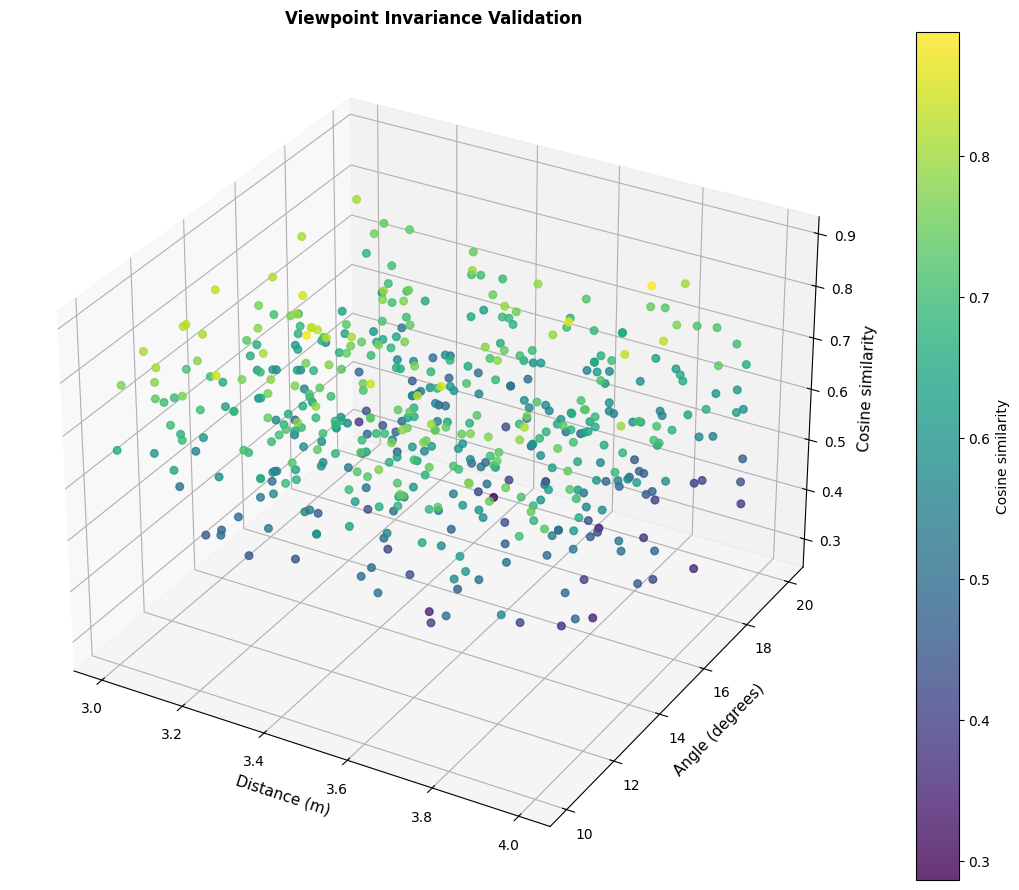

In [20]:
mean_cossim_close_viewpoint_start, _, _ = pp.viewpoint_invariance_validation(
                                validation_night_to_night,
                                night_expert=night_expert,
                                criterion=(3.0, 4.0, 10.0, 20.0), #TODO: order is min dist, max dist, min angle, max angle!!
                                plot=True
                                )

Evaluating viewpoint variance on validation set...
min dist: 50.0, max dist: 60.0, min angle: 20.0, max_angle:180.0
Number of pairs within criterion: 1000 / 10000


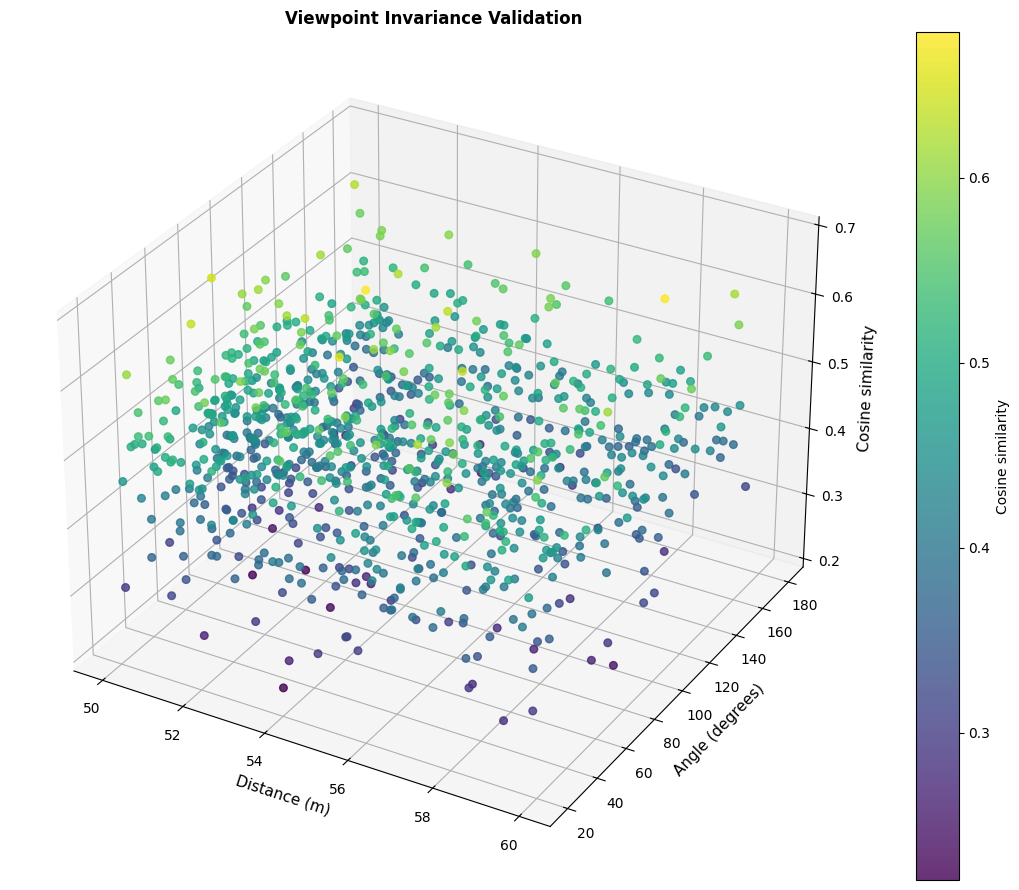

In [23]:
mean_cossim_far_viewpoint_start, _, _ = pp.viewpoint_invariance_validation(
                                validation_night_to_night,
                                night_expert=night_expert,
                                criterion=(50.0, 60.0, 20.0, 180.0), #TODO: order is min dist, max dist, min angle, max angle!!
                                plot=True
                                )

In [24]:
print(mean_cossim_close_viewpoint_start, mean_cossim_far_viewpoint_start)

0.6353505849838257 0.4419809579849243


In [ ]:
print(mean_cossim_illumination)

In [64]:
val_results = validate_during_training(
    model=day_expert,
    val_db_loader=val_db_loader,
    val_day_query_loader=val_day_query_loader,
    val_night_query_loader=val_night_query_loader,
    val_db_image_names=val_db_image_names,
    val_day_query_image_names=val_day_query_image_names,
    val_night_query_image_names=val_night_query_image_names,
    val_db_poses=val_db_poses,
    val_day_query_poses=val_day_query_poses,
    val_night_query_poses=val_night_query_poses,
    device=device,
    epoch=0
)


Validation nach Epoch 0
  Computing embeddings for database...
  Computing embeddings for day queries...
  Computing embeddings for night queries...

  Evaluating Day Queries...
  Evaluating Night Queries...

  Day Queries:
    Recall@1: 47.82%
    Recall@5: 71.54%
    Recall@10: 78.19%

  Night Queries:
    Recall@1: 8.47%
    Recall@5: 17.28%
    Recall@10: 22.34%



Evaluating viewpoint variance on validation set...
Number of pairs within criterion: 727 / 4000


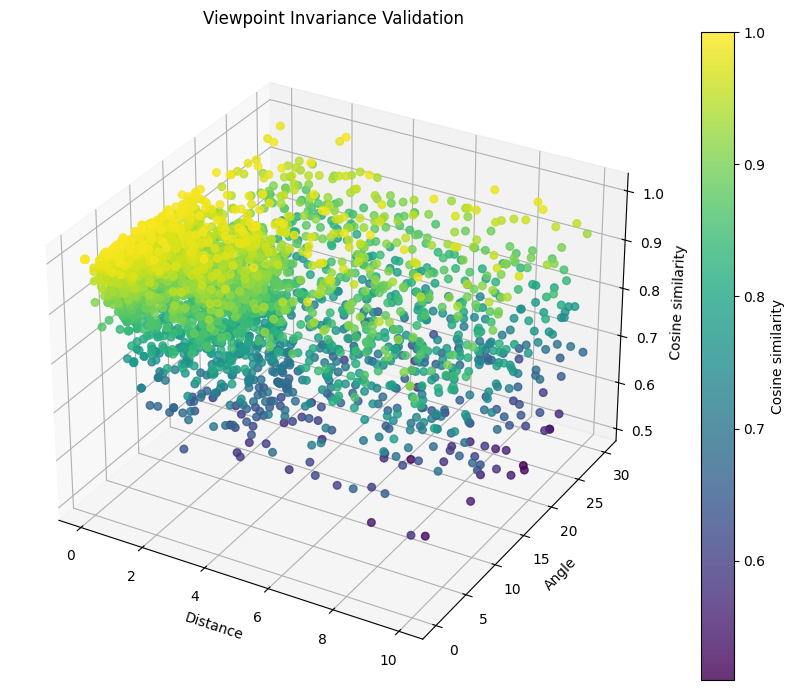

In [ ]:
mean_cossim_viewpoint_1, results_viewpoint_inv_1, coefficients = pp.viewpoint_invariance_validation(
                                validation_night_to_night,
                                night_expert=night_expert,
                                criterion=(2.5, 3.5, 10.0, 15.0), #TODO: order is min dist, max dist, min angle, max angle!!
                                plot=True
                                )

In [67]:
print(mean_cossim_viewpoint_1)

0.8277596235275269


In [63]:
print(f"Evaluiere cluster assignment accuracy auf training set...")
predicted_labels = []
true_labels = []
for img_night, img_day, labels in train_loader:
    img_night = img_night.to(device)
    img_day = img_day.to(device)
    labels = labels.to(device)
    
    with torch.no_grad():
        feats_night = night_expert(img_night)
        W_norm = F.normalize(lmc_module.W, p=2, dim=0)
        logits_night = torch.matmul(F.normalize(feats_night, p=2, dim=1), W_norm)
        preds = torch.argmax(logits_night, dim=1)
        predicted_labels.extend(preds.cpu().numpy())
        true_labels.extend(labels.cpu().numpy())
predicted_labels = np.array(predicted_labels)
true_labels = np.array(true_labels)
accuracy = np.mean(predicted_labels == true_labels)
print(f"  Cluster Assignment Accuracy auf Training Set: {accuracy*100:.2f}%\n")

Evaluiere cluster assignment accuracy auf training set...


NameError: name 'train_loader' is not defined

In [123]:
print(config_dict)

{'num_classes': [374, 1351, 1090, 821], 'num_total_classes': np.int64(3636), 'batch_size': 16, 'alpha': 50.0, 'spatial_filtering_dist_threshold': 0.1, 'spatial_filtering_rot_threshold': 3.0, 'location_clustering_dist_threshold': 1.5, 'location_clustering_rot_weight': 1.0, 'location_clustering_dist_threshold_new': 3.0, 'location_clustering_rot_weight_new': 10.0, 'day_night_pairing_dist_threshold': 3.0, 'day_night_pairing_rot_threshold': 10.0, 'num_epochs': 1, 'min_imgs_per_cluster': 1, 'max_imgs_per_cluster': 5}


Compute benchmark for VPR based on normal CosPlace


-
-
-
Tests
-
-
-


In [ ]:
# plot cluster sizes (pairs per cluster)

import matplotlib.pyplot as plt
cluster_sizes = {}
for pair in new_pairs:
    if pair['label'] in cluster_sizes.keys():
        cluster_sizes[pair['label']] += 1
    else: 
        cluster_sizes[pair['label']] = 1
sizes = np.array(list(cluster_sizes.values()))
sizes = [int(sizes[i]) for i in range(len(sizes)) if sizes[i] < 30]

print(sizes)
plt.hist(sizes)

Number of clusters: 3636
Number of poses in day_dict_flat: 18341
Visualizing 1105 cluster centers
375
1724


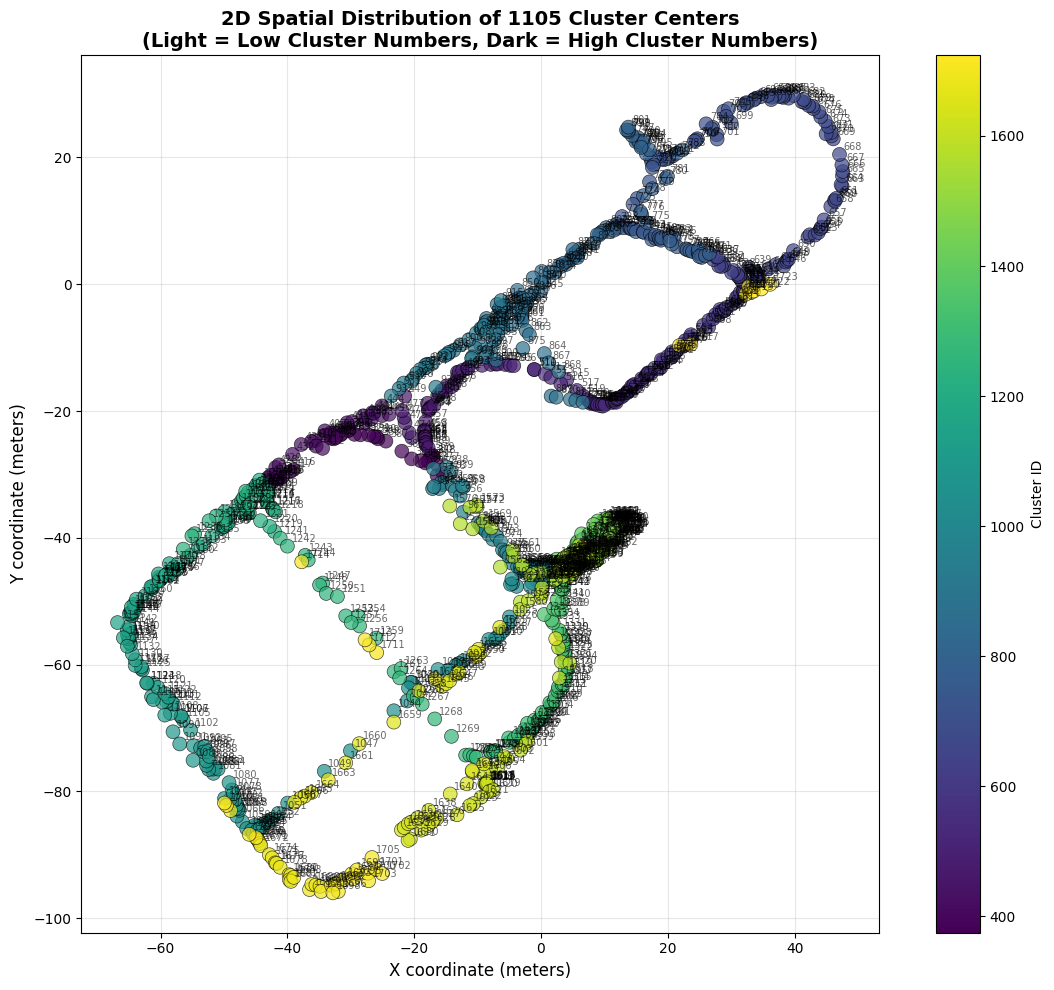


Cluster Center Statistics:
  X range: [-66.78, 47.60] meters
  Y range: [-95.99, 29.81] meters
  X span: 114.38 meters
  Y span: 125.80 meters


In [38]:
# Visualize cluster centers
import matplotlib.pyplot as plt

print(f"Number of clusters: {len(cluster_center_labeled_dict_flat)}")
print(f"Number of poses in day_dict_flat: {len(day_dict_flat)}")

fig, ax, cluster_coords = pp.visualize_cluster_centers_2d(cluster_center_labeled_dict_flat, day_dict_flat, scene_number=1, num_classes=NUM_CLASSES)
plt.show()

# Print statistics
if len(cluster_coords) > 0:
    x_vals = [coord[0] for coord in cluster_coords.values()]
    y_vals = [coord[1] for coord in cluster_coords.values()]
    print(f"\nCluster Center Statistics:")
    print(f"  X range: [{min(x_vals):.2f}, {max(x_vals):.2f}] meters")
    print(f"  Y range: [{min(y_vals):.2f}, {max(y_vals):.2f}] meters")
    print(f"  X span: {max(x_vals) - min(x_vals):.2f} meters")
    print(f"  Y span: {max(y_vals) - min(y_vals):.2f} meters")

Evaluating viewpoint variance on validation set...
min dist: 50.0, max dist: 60.0, min angle: 30.0, max_angle:360.0
Number of pairs within criterion: 1000 / 10000
Fitting 2D polynomial surface to data...
Surface fitting complete. Polynomial coefficients: [-3.8282898e-01  3.5259105e-02 -2.3685708e-03 -3.5725918e-04
  1.2639453e-06  3.4878525e-05]


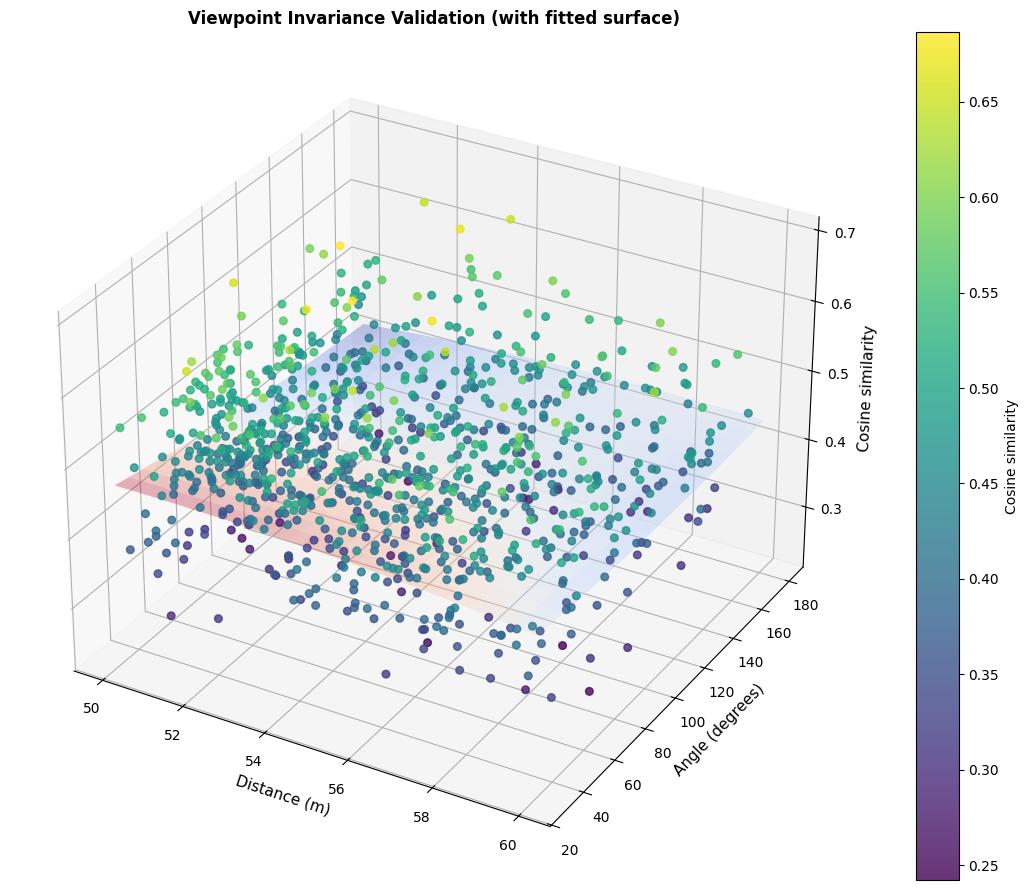

In [42]:
# Check viewpoint invariance based on the day expert and plot

# ca 50s per call
cossim_far_viewpoint, results, coefficients = pp.viewpoint_invariance_validation(
    validation_night_to_night,
    night_expert=day_expert,
    criterion=(50.0, 60.0, 30.0, 360.0),
    plot=True,
    fit_surface=True
)

Evaluating viewpoint variance on validation set...
min dist: 3.0, max dist: 4.0, min angle: 10.0, max_angle:20.0
Number of pairs within criterion: 329 / 10000
Fitting 2D polynomial surface to data...
Surface fitting complete. Polynomial coefficients: [-5.1503026e-01  8.2358146e-01 -2.7405867e-02 -1.2106004e-01
  6.2844361e-04  5.9747486e-04]


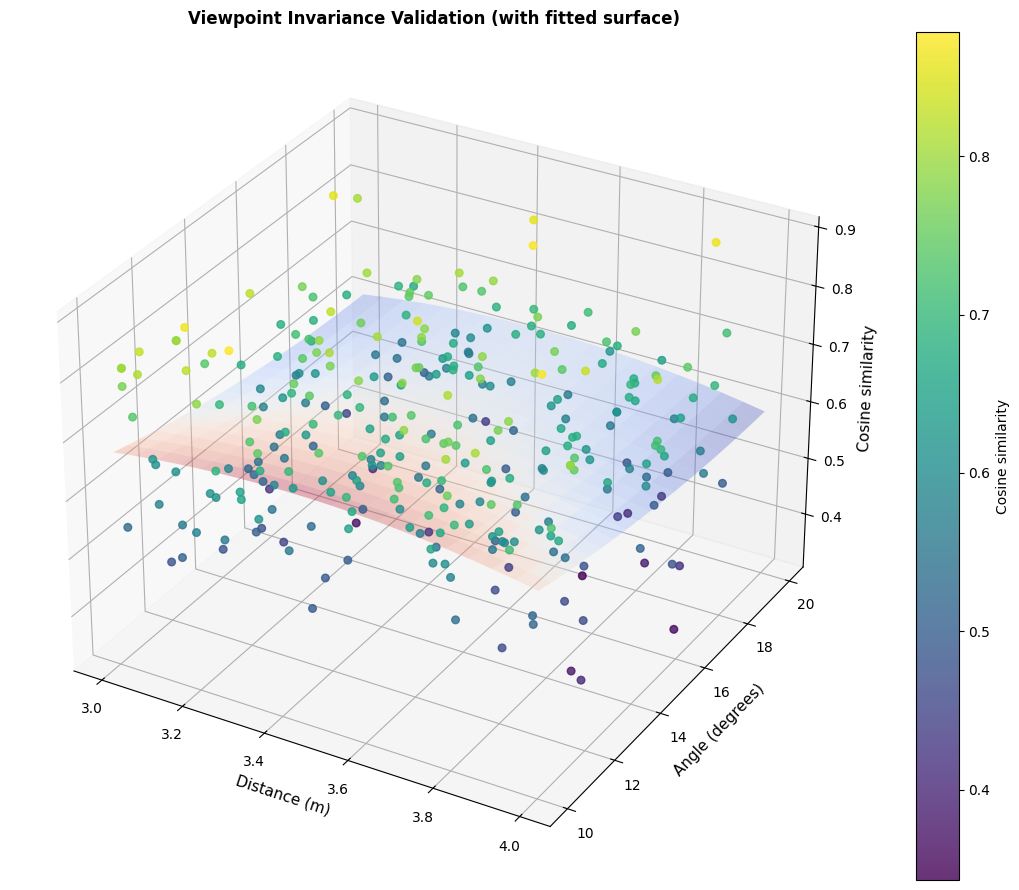

In [43]:
# Check viewpoint invariance based on the day expert and plot

# ca 50s per call
cossim_close_viewpoint, results_close, coefficients_close = pp.viewpoint_invariance_validation(
    validation_night_to_night,
    night_expert=day_expert,
    criterion=(3.0, 4.0, 10.0, 20.0),
    plot=True,
    fit_surface=True
)

In [45]:
thresh = cossim_close_viewpoint - cossim_far_viewpoint
print(thresh)

0.2014394998550415


In [39]:
1/(4*coefficients[3]*coefficients[4]-coefficients[5]**2) * np.array([[2*coefficients[4], -coefficients[5]], [-coefficients[5], 2*coefficients[3]]]) @ np.array([[-coefficients[1]], [-coefficients[2]]])

array([[18.682262],
       [34.636276]], dtype=float32)

Evaluating viewpoint variance on validation set...
min dist: 3.0, max dist: 4.0, min angle: 10.0, max_angle:15.0
Number of pairs within criterion: 267 / 15000


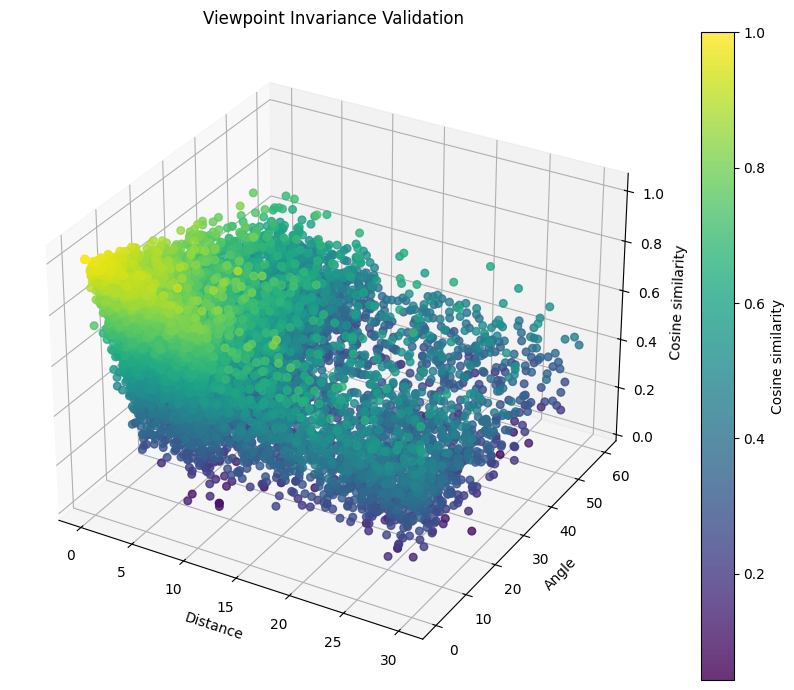

In [ ]:
avg_sim, results, coefficients = pp.viewpoint_invariance_validation(
    validation_day_to_day,
    night_expert=day_expert,
    criterion=(3.0, 4.0, 10.0, 15.0),
    plot=True
)

In [28]:
print(avg_sim)

0.596335232257843


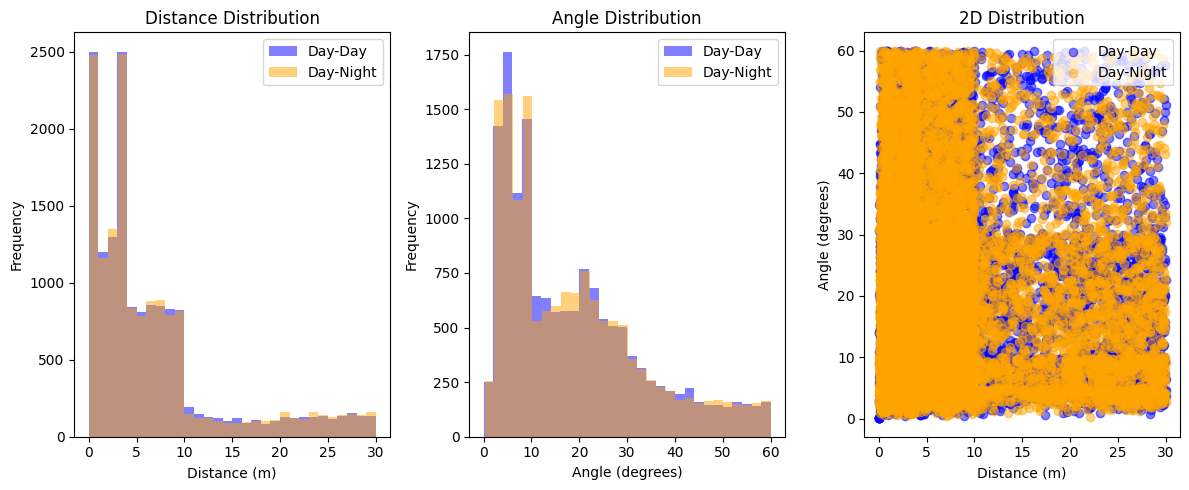

In [23]:
# plot angle and distance distributions for day-to-day and day-to-night pairs
day_day_pairs = validation_day_to_day.pairs
day_night_pairs = validation_day_to_night.pairs
dist_angle_day_day = [(pair['distance'], pair['angle']) for pair in day_day_pairs]
dist_angle_day_night = [(pair['distance'], pair['angle']) for pair in day_night_pairs]

# plotting
import matplotlib.pyplot as plt
dist_day_day, angle_day_day = zip(*dist_angle_day_day)
dist_day_night, angle_day_night = zip(*dist_angle_day_night)    
# plot histograms and 2D plots
plt.figure(figsize=(12, 5))
plt.subplot(1, 3, 1)
plt.hist(dist_day_day, bins=30, alpha=0.5, label='Day-Day', color='blue')
plt.hist(dist_day_night, bins=30, alpha=0.5, label='Day-Night', color='orange')
plt.title('Distance Distribution')
plt.xlabel('Distance (m)')
plt.ylabel('Frequency')
plt.legend()
plt.subplot(1, 3, 2)
plt.hist(angle_day_day, bins=30, alpha=0.5, label='Day-Day', color='blue')
plt.hist(angle_day_night, bins=30, alpha=0.5, label='Day-Night', color='orange')
plt.title('Angle Distribution')
plt.xlabel('Angle (degrees)')
plt.ylabel('Frequency')
plt.legend()
plt.subplot(1, 3, 3)
# plot 2D scatter plots
plt.scatter(dist_day_day, angle_day_day, alpha=0.5, label='Day-Day', color='blue')
plt.scatter(dist_day_night, angle_day_night, alpha=0.5, label='Day-Night', color='orange')
plt.title('2D Distribution')
plt.xlabel('Distance (m)')
plt.ylabel('Angle (degrees)')
plt.legend()
plt.tight_layout()
plt.show()

In [16]:
# count the number of clusters with at least one night image
clusters_with_night = set(night_labels.values())
print(f"Number of clusters with at least one night image: {len(clusters_with_night)} out of {len(set(day_labels.values()))} total clusters.")
# print the number of night images assigned to each cluster
from collections import Counter
night_cluster_counts = Counter(night_labels.values())
for cluster_id, count in night_cluster_counts.items():
    print(f"Cluster {cluster_id}: {count} night images")

Number of clusters with at least one night image: 2957 out of 2957 total clusters.
Cluster 232: 9 night images
Cluster 78: 1 night images
Cluster 280: 3 night images
Cluster 350: 1 night images
Cluster 82: 4 night images
Cluster 300: 3 night images
Cluster 63: 1 night images
Cluster 97: 1 night images
Cluster 101: 6 night images
Cluster 107: 3 night images
Cluster 3: 2 night images
Cluster 109: 1 night images
Cluster 46: 2 night images
Cluster 22: 15 night images
Cluster 201: 3 night images
Cluster 246: 10 night images
Cluster 23: 6 night images
Cluster 15: 23 night images
Cluster 155: 16 night images
Cluster 285: 7 night images
Cluster 329: 10 night images
Cluster 249: 7 night images
Cluster 145: 1 night images
Cluster 26: 7 night images
Cluster 304: 3 night images
Cluster 62: 2 night images
Cluster 92: 4 night images
Cluster 93: 28 night images
Cluster 89: 9 night images
Cluster 21: 8 night images
Cluster 279: 6 night images
Cluster 79: 7 night images
Cluster 5: 113 night images
Clus

In [17]:
# test dict access
print(day_dict[day_image_names[0]]['c_world'])
print(day_dict[day_image_names[0]]['R_c2w'])
print(night_dict[night_image_names[0]]['c_world'])
print(night_dict[night_image_names[0]]['R_c2w'])
print(day_dict[day_image_names[0]])

TypeError: list indices must be integers or slices, not list

Random Pair: {'night_img': '672369346000.jpg', 'day_img': np.str_('528640578950.jpg'), 'dist': 0.7397873712014101, 'angle': 3.4707885028472885, 'label': np.int64(1313)}


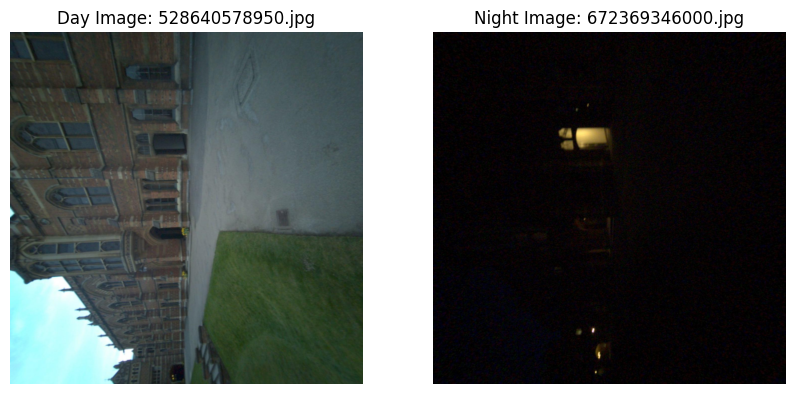

In [76]:
# Show a random image pair from new_pairs
import random
import matplotlib.pyplot as plt
random_pair = random.choice(new_pairs)
print(f"Random Pair: {random_pair}")
day_img_name = random_pair['day_img']
day_img_path = global_path_map[day_img_name]
night_img_name = random_pair['night_img']
night_img_path = global_path_map[night_img_name]
day_image = Image.open(day_img_path).convert('RGB')
night_image = Image.open(night_img_path).convert('RGB')
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(day_image)
plt.title(f"Day Image: {random_pair['day_img']}")
plt.axis('off')
plt.subplot(1, 2, 2)
plt.imshow(night_image)
plt.title(f"Night Image: {random_pair['night_img']}")
plt.axis('off')
plt.show()

In [62]:
print(day_dict[0][random_pair['day_img']])

KeyError: np.str_('142372432600.jpg')

In [120]:
# Show a few pairs
random_indices = np.random.choice(len(pairs), size=min(3, len(pairs)), replace=False)
random_indices = [100, 101, 102] if len(pairs) >= 3 else list(range(len(pairs)))  # For reproducibility in this example
for i in random_indices:
    print(f"Pair {i+1}: Night Image: {pairs[i][0]}, Day Image: {pairs[i][1]}, Distance: {pairs[i][2]:.2f}, Angle Diff: {pairs[i][3]:.2f}°, Cluster ID: {pairs[i][4]}")
    # Show images, you have to adjust the paths based on your setup: the vrs** info is lost in the clean_name, so we need to find the corresponding file in the folder
    # look for the night image file
    night_img_path = None
    for file in night_images_root.glob('*.jpg'):
        if file.name.endswith(pairs[i][0]):
            night_img_path = file
            break
    # look for the day image file
    day_img_path = None 
    for file in day_images_root.glob('*.jpg'):
        if file.name.endswith(pairs[i][1]):
            day_img_path = file
            break
    # show jpg images
    from PIL import Image
    import matplotlib.pyplot as plt
    night_img = Image.open(night_img_path)
    day_img = Image.open(day_img_path)
    plt.figure(figsize=(10, 5))
    plt.subplot(1, 2, 1)
    plt.imshow(night_img)
    plt.title(f"Night: {pairs[i][0]}")
    plt.axis('off')
    plt.subplot(1, 2, 2)
    plt.imshow(day_img)
    plt.title(f"Day: {pairs[i][1]}")
    plt.axis('off')
    plt.show()

IndexError: list index out of range

In [ ]:
# show all images of cluster 0
cluster_index = pairs[0][4]  # Cluster ID des ersten Paares

cluster_0_day_images = [name for name, label in day_labels.items() if label == cluster_index]
print(f"Cluster 0 contains {len(cluster_0_day_images)} day images.")
for img_name in cluster_0_day_images:
    print(f"translation of {img_name}: ", day_dict[img_name]['c_world'])
    img_path = None
    for file in day_images_root.glob('*.jpg'):
        if file.name.endswith(img_name):
            img_path = file
            break
    img = Image.open(img_path)
    plt.imshow(img)
    plt.title(f"Cluster 0: {img_name}")
    plt.axis('off')
    plt.show()


cluster_0_night_images = [name for name, label in night_labels.items() if label == cluster_index]
print(f"Cluster 0 contains {len(cluster_0_night_images)} night images.")
for img_name in cluster_0_night_images:
    print(f"translation of {img_name}: ", night_dict[img_name]['c_world'])
    img_path = None
    for file in night_images_root.glob('*.jpg'):
        if file.name.endswith(img_name):
            img_path = file
            break
    img = Image.open(img_path)
    plt.imshow(img)
    plt.title(f"Cluster 0: {img_name}")
    plt.axis('off')
    plt.show()

In [82]:
# Find a day and a night image with similar translation and rotation (small distance and angle difference) and show them side by side
n = 5
random_indices = np.random.choice(len(pairs), size=min(n, len(pairs)), replace=False)
for i in random_indices:
    if(pairs[i][2] < 1.0 and pairs[i][3] < 5.0):
        print(f"Pair {i+1}: Night Image: {pairs[i][0]}, Day Image: {pairs[i][1]}, Distance: {pairs[i][2]:.2f}, Angle Diff: {pairs[i][3]:.2f}°")
        # Show images
        night_img_path = None
        for file in night_images_root.glob('*.jpg'):
            if file.name.endswith(pairs[i][0]):
                night_img_path = file
                break
        day_img_path = None
        for file in day_images_root.glob('*.jpg'):
            if file.name.endswith(pairs[i][1]):
                day_img_path = file
                break
        # show jpg images
        night_img = Image.open(night_img_path)
        day_img = Image.open(day_img_path)
        plt.figure(figsize=(10, 5))
        plt.subplot(1, 2, 1)
        plt.imshow(night_img)
        plt.title(f"Night: {pairs[i][0]}")
        plt.axis('off')
        plt.subplot(1, 2, 2)
        plt.imshow(day_img)
        plt.title(f"Day: {pairs[i][1]}")
        plt.axis('off')
        plt.show()

TypeError: '<' not supported between instances of 'tuple' and 'float'

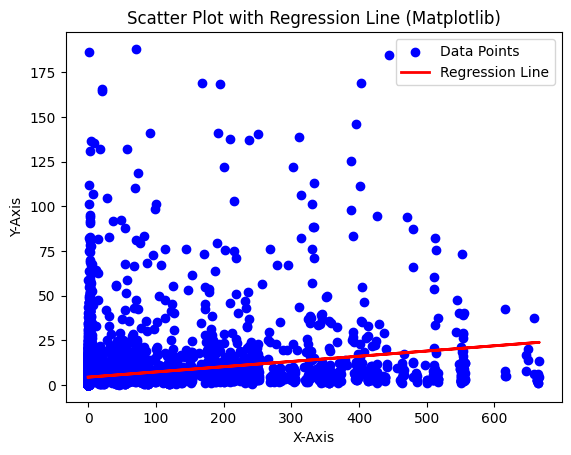

In [96]:
distances = np.zeros(len(new_pairs))
labeldiffs = np.zeros_like(distances)
for i in range(len(new_pairs) - 1):
    img_name = new_pairs[i]["day_img"]
    for j in range(len(day_dict)):
        try:
            position_a = day_dict[j][img_name]['t_w2c_orig']
            label_a = new_pairs[i]["label"]
            break
        except:
            continue
    img_name = new_pairs[i+1]["day_img"]
    for j in range(len(day_dict)):
        try:
            position_b = day_dict[j][img_name]['t_w2c_orig']
            label_b = new_pairs[i+1]["label"]
            break
        except:
            continue
    dist = np.linalg.norm(position_a - position_b)
    label_diff = np.abs(label_a - label_b)
    distances[i] = dist
    labeldiffs[i] = label_diff

x = labeldiffs
y = distances

# 1. Plot the dots (scatter plot)
plt.scatter(x, y, color="blue", label="Data Points")

# 2. Calculate the linear regression line (degree 1 polynomial)
m, b = np.polyfit(x, y, 1)

# 3. Plot the regression line using the equation: y = mx + b
plt.plot(x, m * x + b, color="red", linewidth=2, label="Regression Line")

# Add elements and show
plt.title("Scatter Plot with Regression Line (Matplotlib)")
plt.xlabel("X-Axis")
plt.ylabel("Y-Axis")
plt.legend()
plt.show()


In [91]:
print(day_dict[0])

{'35350735662.jpg': {'c_world': array([ 19.01434328, -10.17696687,  -0.02745672]), 'R_c2w': array([[-8.51043045e-04,  7.61921203e-01, -6.47669172e-01],
       [-7.33192942e-02, -6.45973757e-01, -7.59830367e-01],
       [-9.97308155e-01,  4.68399982e-02,  5.64132763e-02]]), 'R_w2c_orig': array([[-8.51043045e-04, -7.33192942e-02, -9.97308155e-01],
       [ 7.61921203e-01, -6.45973757e-01,  4.68399982e-02],
       [-6.47669172e-01, -7.59830367e-01,  5.64132763e-02]]), 't_w2c_orig': array([ -0.75736881, -21.06019876,   4.58378441])}, '36350736787.jpg': {'c_world': array([ 18.75737177, -10.38339002,  -0.07562938]), 'R_c2w': array([[-0.0234297 ,  0.6645923 , -0.74683875],
       [-0.03150664, -0.74716361, -0.66389297],
       [-0.99922889,  0.00797557,  0.03844489]]), 'R_w2c_orig': array([[-0.0234297 , -0.03150664, -0.99922889],
       [ 0.6645923 , -0.74716361,  0.00797557],
       [-0.74683875, -0.66389297,  0.03844489]]), 't_w2c_orig': array([  0.03676273, -20.22349291,   7.11818002])}, '

In [87]:
new_pairs[0]["day_img"]

'1482290562975.jpg'

In [ ]:
# Find 3 classes with exactly 4 image pairs
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

# Count pairs per label
cluster_sizes = {}
for pair in new_pairs:
    if pair['label'] in cluster_sizes.keys():
        cluster_sizes[pair['label']] += 1
    else: 
        cluster_sizes[pair['label']] = 1

# Find indices where size == 4
labels_with_4_pairs = [label for label, size in cluster_sizes.items() if size == 4]
print(f"Found {len(labels_with_4_pairs)} classes with exactly 4 pairs")
print(f"Classes with 4 pairs: {labels_with_4_pairs[10:13]}")

# Get the first 3 classes with 4 pairs
classes_to_show = labels_with_4_pairs[10:13]

# For each class, get the day image names and show the pictures
for class_label in classes_to_show:
    print(f"\n=== Class {class_label} with 4 image pairs ===")
    
    # Get all pairs for this class
    class_pairs = [pair for pair in new_pairs if pair['label'] == class_label]
    
    # Create a grid showing all 4 day images for this class
    fig, axes = plt.subplots(2, 2, figsize=(12, 10))
    fig.suptitle(f'Class {class_label} - 4 Day Images', fontsize=16)
    axes = axes.flatten()
    
    for idx, pair in enumerate(class_pairs):
        day_img_name = pair['day_img']
        print(f"  Pair {idx+1}: Day Image: {day_img_name}, Night Image: {pair['night_img']}")
        
        # Find the full path to the day image
        day_img_path = None
        for file in day_images_roots[0].glob('*.jpg'):  # Using first training scene
            if file.name.endswith(day_img_name):
                day_img_path = file
                break
        
        if day_img_path and day_img_path.exists():
            day_img = Image.open(day_img_path)
            axes[idx].imshow(day_img)
            axes[idx].set_title(f"Day Image {idx+1}: {day_img_name}")
            axes[idx].axis('off')
    
    plt.tight_layout()
    plt.show()

print("\nDone showing 3 classes with 4 image pairs each!")

In [ ]:
classes = [1, 1, 2, 12, 32, 72]

# Find the full path to the day image

fig, axes = plt.subplots(2, 3, figsize=(12, 10))
#fig.suptitle(f'Class {class_label} - 4 Day Images', fontsize=16)
axes = axes.flatten()
counter = 0
for c in classes:
    day_img_name = cluster_center_labeled_dict_flat[c]

    day_img_path = None
    for file in day_images_roots[0].glob('*.jpg'):  # Using first training scene
        if file.name.endswith(day_img_name):
            day_img_path = file
            break
    
    if day_img_path is None:
        print("day_img_path is None")
    if not day_img_path.exists():
        print("day_img_path doesnt exist")

    if day_img_path and day_img_path.exists():
        day_img = Image.open(day_img_path)
        plt.show(day_img)
    counter+=1